## Preliminary

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('./UPL25_matches2.csv')

In [2]:
df.shape

(3988, 90)

In [3]:
cat_cols = [col for col in df.columns if df[col].dtype == 'object']
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns#all numeric columns
num_cols = ['duration','distance_km','sprint_distance_m','power_plays','energy_kcal','impacts',
                   'player_load','top_speed_kmh','distance_per_min_mmin','power_score_wkg','work_ratio','max_acceleration_mss','max_deceleration_mss']# numeric columns of high interest
intensity_metrics =['player_load','top_speed_kmh','distance_per_min_mmin','power_score_wkg','work_ratio','max_acceleration_mss','max_deceleration_mss']
volume_metrics = ['distance_km','sprint_distance_m','power_plays','energy_kcal','impacts']


In [4]:
from IPython.display import HTML

def style_table_for_docs(df, hide_index=False):
    styled = (
        df.style
        .set_properties(**{
            'color': 'black',
            'background-color': 'white',
            'border': '1px solid black',
            'text-align': 'center',
            'padding': '2px'  # reduces row height
        })
        .set_table_styles([
            {'selector': 'th', 'props': [
                ('color', 'black'), 
                ('border', '1px solid black'),
                ('padding', '2px')  # also reduce header row height
            ]},
            {'selector': 'td', 'props': [
                ('color', 'black'), 
                ('border', '1px solid black'),
                ('padding', '2px')
            ]},
            {'selector': 'table', 'props': [
                ('border', '2px solid black'), 
                ('border-collapse', 'collapse')
            ]}
        ])
    )
    
    if hide_index:
        styled = styled.hide(axis='index')

    return styled



In [5]:
df['total_accelerations'] = df[
	[
		'accelerations_zone_count:_1__2_mss',
		'accelerations_zone_count:_2__3_mss',
		'accelerations_zone_count:_3__4_mss',
		'accelerations_zone_count:_>_4_mss'
	]
].sum(axis=1)

df['total_decelerations'] = df[
	[
		'deceleration_zone_count:_1__2_mss',
		'deceleration_zone_count:_2__3_mss',
		'deceleration_zone_count:_3__4_mss',
		'deceleration_zone_count:_>_4_mss'
	]
].sum(axis=1)


In [6]:
volume_metrics.append('total_accelerations')
volume_metrics.append('total_decelerations')

df['acc_counts_per_min'] = df['total_accelerations'] / df['duration']
df['dec_counts_per_min'] = df['total_decelerations'] / df['duration']

intensity_metrics.append('acc_counts_per_min')
intensity_metrics.append('dec_counts_per_min')

## Summary

In [7]:
table1 = df[['player_load','power_score_wkg','work_ratio']].agg(['sum', 'mean', 'std']).T
style_table_for_docs(table1.round(2))

,sum,mean,std
player_load,1559385.490000,391.020000,103.500000
power_score_wkg,55659.320000,13.960000,4.060000
work_ratio,288751.290000,72.410000,23.000000


In [8]:
summary_table_intensity = df[intensity_metrics].agg(['max', 'mean', 'std']).T
style_table_for_docs(summary_table_intensity.round(2))

,max,mean,std
player_load,655.960000,391.020000,103.500000
top_speed_kmh,36.420000,29.590000,2.300000
distance_per_min_mmin,136.520000,86.750000,24.920000
power_score_wkg,21.990000,13.960000,4.060000
work_ratio,122.170000,72.410000,23.000000
max_acceleration_mss,10.000000,5.850000,0.630000
max_deceleration_mss,10.000000,7.160000,0.970000
acc_counts_per_min,7.110000,4.050000,1.230000
dec_counts_per_min,6.710000,3.890000,1.190000


In [9]:
summary_table_volume = df[volume_metrics].agg(['sum','mean', 'std']).T
style_table_for_docs(summary_table_volume.round(2))

,sum,mean,std
distance_km,33921.710000,8.510000,2.450000
sprint_distance_m,3364024.130000,843.540000,379.160000
power_plays,240174.000000,60.220000,23.060000
energy_kcal,4150620.970000,1040.780000,304.810000
impacts,25101.000000,6.290000,4.860000
total_accelerations,1583565.000000,397.080000,121.360000
total_decelerations,1519838.000000,381.100000,117.140000


## Data Overview

In [10]:
unique_players_per_club = df.groupby('club_for')['p_name'].nunique().reset_index()
unique_players_per_club.columns = ['club_for', 'unique_players']
style_table_for_docs(unique_players_per_club.sort_values(by='unique_players', ascending=False))

,club_for,unique_players
7,Mbarara City Fc,30
15,Wakiso Giants Fc,28
3,Kitara Fc,27
0,Bul Fc,27
14,Vipers Sc,27
9,Police Fc,26
4,Lugazi Fc,26
2,Kcca Fc,26
13,Ura Fc,25
8,Nec Fc,24


In [11]:
players_match_days = df.groupby(['p_name', 'player_club_'])['match_day'].nunique().reset_index()
players_match_days.columns = ['p_name', 'player_club_', 'unique_match_days']
style_table_for_docs(players_match_days.sort_values(by='unique_match_days', ascending=False).head(10))

,p_name,player_club_,unique_match_days
102,Emmanuel Obua,Lugazi Fc,27
320,Rogers Ochaki Torach,Vipers Sc,26
324,Ronald Otti,Kitara Fc,26
37,Ayiko Richard,Lugazi Fc,26
338,Seiri Arigumaho,Mbarara City Fc,26
274,Nelson Senkatuka,Soltilo Bright Stars Fc,26
116,Francis Odongo,Mbarara City Fc,26
35,Atendele Geriga,Nec Fc,26
13,Ali Arshavin Bayo,Lugazi Fc,26
3,Abdulkarim Watambala,Vipers Sc,26


In [12]:
# Calculate average number of unique players per matchday for each club
players_per_club_day = df.groupby(['club_for', 'match_day'])['p_name'].nunique().reset_index()
avg_players_per_matchday = players_per_club_day.groupby('club_for')['p_name'].mean().reset_index()
avg_players_per_matchday.columns = ['club_for', 'avg_players_per_matchday']
style_table_for_docs(avg_players_per_matchday.sort_values(by='avg_players_per_matchday', ascending=False))

,club_for,avg_players_per_matchday
5,Maroons Fc,11.200000
13,Ura Fc,11.160000
4,Lugazi Fc,11.066667
15,Wakiso Giants Fc,11.040000
7,Mbarara City Fc,11.033333
8,Nec Fc,10.933333
3,Kitara Fc,10.571429
1,Express Fc,10.333333
14,Vipers Sc,9.896552
12,Updf Fc,9.827586


In [13]:
# Count the number of unique matchdays for each club
unique_matchdays_per_club = df.groupby('club_for')['match_day'].nunique().reset_index()
unique_matchdays_per_club.columns = ['club_for', 'unique_matchdays']
style_table_for_docs(unique_matchdays_per_club.sort_values(by='unique_matchdays', ascending=False))

,club_for,unique_matchdays
0,Bul Fc,30
4,Lugazi Fc,30
7,Mbarara City Fc,30
8,Nec Fc,30
12,Updf Fc,29
14,Vipers Sc,29
11,Soltilo Bright Stars Fc,29
2,Kcca Fc,28
3,Kitara Fc,28
9,Police Fc,27


C:\Users\Travail\AppData\Local\Temp\ipykernel_14048\4174563128.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([lbl.get_text().upper() for lbl in ax.get_xticklabels()], rotation=90, fontsize=9)


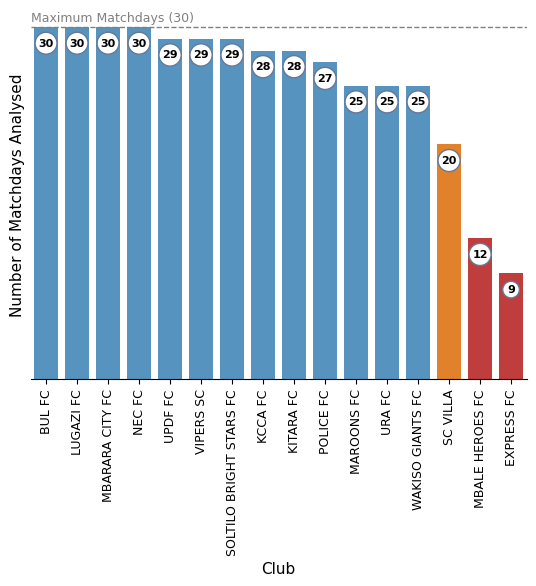

In [14]:
# Sort data
data = unique_matchdays_per_club.sort_values(by='unique_matchdays', ascending=False)

# Define usage tiers and corresponding colors
def usage_tier_color(val):
    if val >= 25:
        return "#4596cf"  # dark blue for high engagement
    elif val >= 16:
        return '#ff7f0e'  # orange for medium
    else:
        return '#d62728'  # red for low

colors = data['unique_matchdays'].map(usage_tier_color).tolist()

# Create barplot
# plt.figure(figsize=(12,6))
sns.barplot(data=data, x='club_for',hue='club_for', y='unique_matchdays', palette=colors,legend=False)

# Benchmark line at maximum matchdays (30)
plt.axhline(30, color='gray', linestyle='--', linewidth=1)
plt.text(-0.5, 30.5, 'Maximum Matchdays (30)', color='gray', fontsize=9)

# Rotate and uppercase x labels
ax = plt.gca()
ax.set_xticklabels([lbl.get_text().upper() for lbl in ax.get_xticklabels()], rotation=90, fontsize=9)

# Title, subtitle, and axis labels
plt.xlabel('Club', fontsize=11)
plt.ylabel('Number of Matchdays Analysed', fontsize=11)

# Gridlines for y-axis
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

# Annotate values inside bars
for i, value in enumerate(data['unique_matchdays']):
    ax.text(
        i, value - 1.8, str(value),
        ha='center', va='bottom',
        fontsize=8, color='black', fontweight='bold',
        bbox=dict(boxstyle="circle,pad=0.30", edgecolor='#667898', facecolor='white', linewidth=1)
    )
#remove yaxis ticklabels
ax.set_yticklabels([])
ax.set_yticks([])


plt.show()


In [15]:
uploaded_matches = {
    "Lugazi FC": 30,
    "URA FC": 30,
    "Vipers SC": 30,
    "Mbarara City FC": 30,
    "Soltilo Bright Stars FC": 29,
    "Police FC": 28,
    "Kitara FC": 29,
    "UPDF FC": 29,
    "KCCA FC": 30,
    "NEC FC": 30,
    "Maroons FC": 25,
    "Wakiso Giants FC": 25,
    "BUL FC": 30,
    "SC Villa": 20,
    "Mbale Heroes FC": 14,
    "Express FC": 9
}

uploaded_matches_df = pd.DataFrame(uploaded_matches.items(), columns=['club_for', 'uploaded_matches'])
uploaded_matches_df['club_for'] = uploaded_matches_df['club_for'].str.title()

uploaded_matches_df=uploaded_matches_df.merge(unique_matchdays_per_club, on='club_for', how='left').sort_values(by='unique_matchdays', ascending=False)
uploaded_matches_df = uploaded_matches_df.rename(columns={
    'uploaded_matches': 'Uploaded Matchdays',
    'unique_matchdays': 'Analysed Matchdays',
})

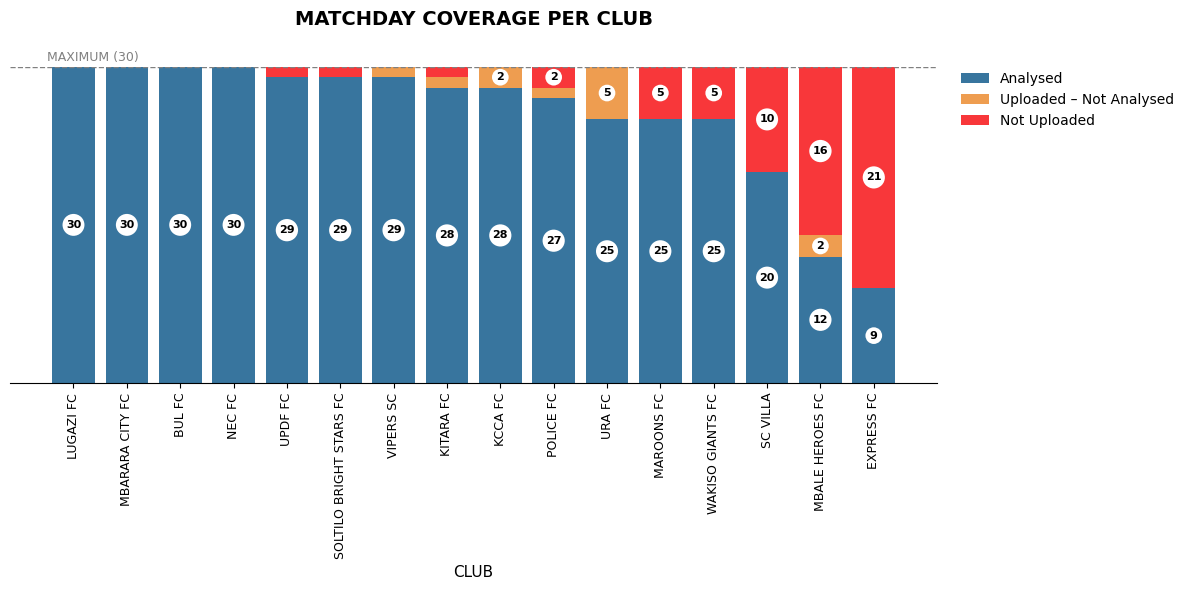

In [16]:

# Prepare DataFrame
uploaded_matches_df_copy = uploaded_matches_df.copy()
uploaded_matches_df_copy['Analysed']      = uploaded_matches_df_copy['Analysed Matchdays']
uploaded_matches_df_copy['Pending']       = uploaded_matches_df_copy['Uploaded Matchdays'] - uploaded_matches_df_copy['Analysed Matchdays']
uploaded_matches_df_copy['not_uploaded']  = 30 - uploaded_matches_df_copy['Uploaded Matchdays']
uploaded_matches_df_copy = uploaded_matches_df_copy.sort_values('Analysed Matchdays', ascending=False)

# Lighter color palette
colors = {
    'Analysed':      "#38759e",  # softer blue
    'Pending':       "#ee9d50",  # softer orange
    'not_uploaded':  "#f8373a"   # softer red
}

fig, ax = plt.subplots(figsize=(12,6))
x = np.arange(len(uploaded_matches_df_copy))

# Plot segments
ax.bar(x, uploaded_matches_df_copy['Analysed'],
       color=colors['Analysed'],
       label='Analysed')
ax.bar(x, uploaded_matches_df_copy['Pending'],
       bottom=uploaded_matches_df_copy['Analysed'],
       color=colors['Pending'],
       label='Uploaded – Not Analysed')
ax.bar(x, uploaded_matches_df_copy['not_uploaded'],
       bottom=uploaded_matches_df_copy['Analysed'] + uploaded_matches_df_copy['Pending'],
       color=colors['not_uploaded'],
       label='Not Uploaded')

# Benchmark line
ax.axhline(30, color='gray', linestyle='--', linewidth=1)
ax.text(-0.5, 30.5, 'MAXIMUM (30)', color='gray', fontsize=9)

# X labels
ax.set_xticks(x)
ax.set_xticklabels(uploaded_matches_df_copy['club_for'].str.upper(), rotation=90, fontsize=9)

# Clean Y axis
ax.set_yticks([])
ax.set_ylabel('')

# Titles
ax.set_xlabel('CLUB', fontsize=11)
ax.set_title('MATCHDAY COVERAGE PER CLUB', fontsize=14, fontweight='bold',pad='30')

# Gridlines
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

# Remove spines
sns.despine(ax=ax, left=True, top=True, right=True)

# Annotation helper
def draw_circle_text(xpos, ypos, txt, color):
    ax.text(
        xpos, ypos, str(int(txt)),
        ha='center', va='center', color='black',
        fontsize=8, fontweight='bold',
        bbox=dict(boxstyle="circle,pad=0.3", facecolor='white', edgecolor='none')
    )

# Annotate segments
for idx, row in enumerate(uploaded_matches_df_copy.itertuples()):
    analysed = row.Analysed
    pending  = row.Pending
    notup    = row.not_uploaded

    # Analysed (always)
    if analysed > 0:
        draw_circle_text(idx, analysed / 2, analysed, colors['Analysed'])

    # Pending (always)
    if pending > 1:
        draw_circle_text(idx, analysed + pending / 2, pending, colors['Pending'])

    # not_uploaded (only if > 1)
    if notup > 1:
        ypos = analysed + pending + notup / 2
        draw_circle_text(idx, ypos, notup, colors['not_uploaded'])

# Legend outside
ax.legend(
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    borderaxespad=0,
    frameon=False
)

plt.tight_layout()
plt.show()


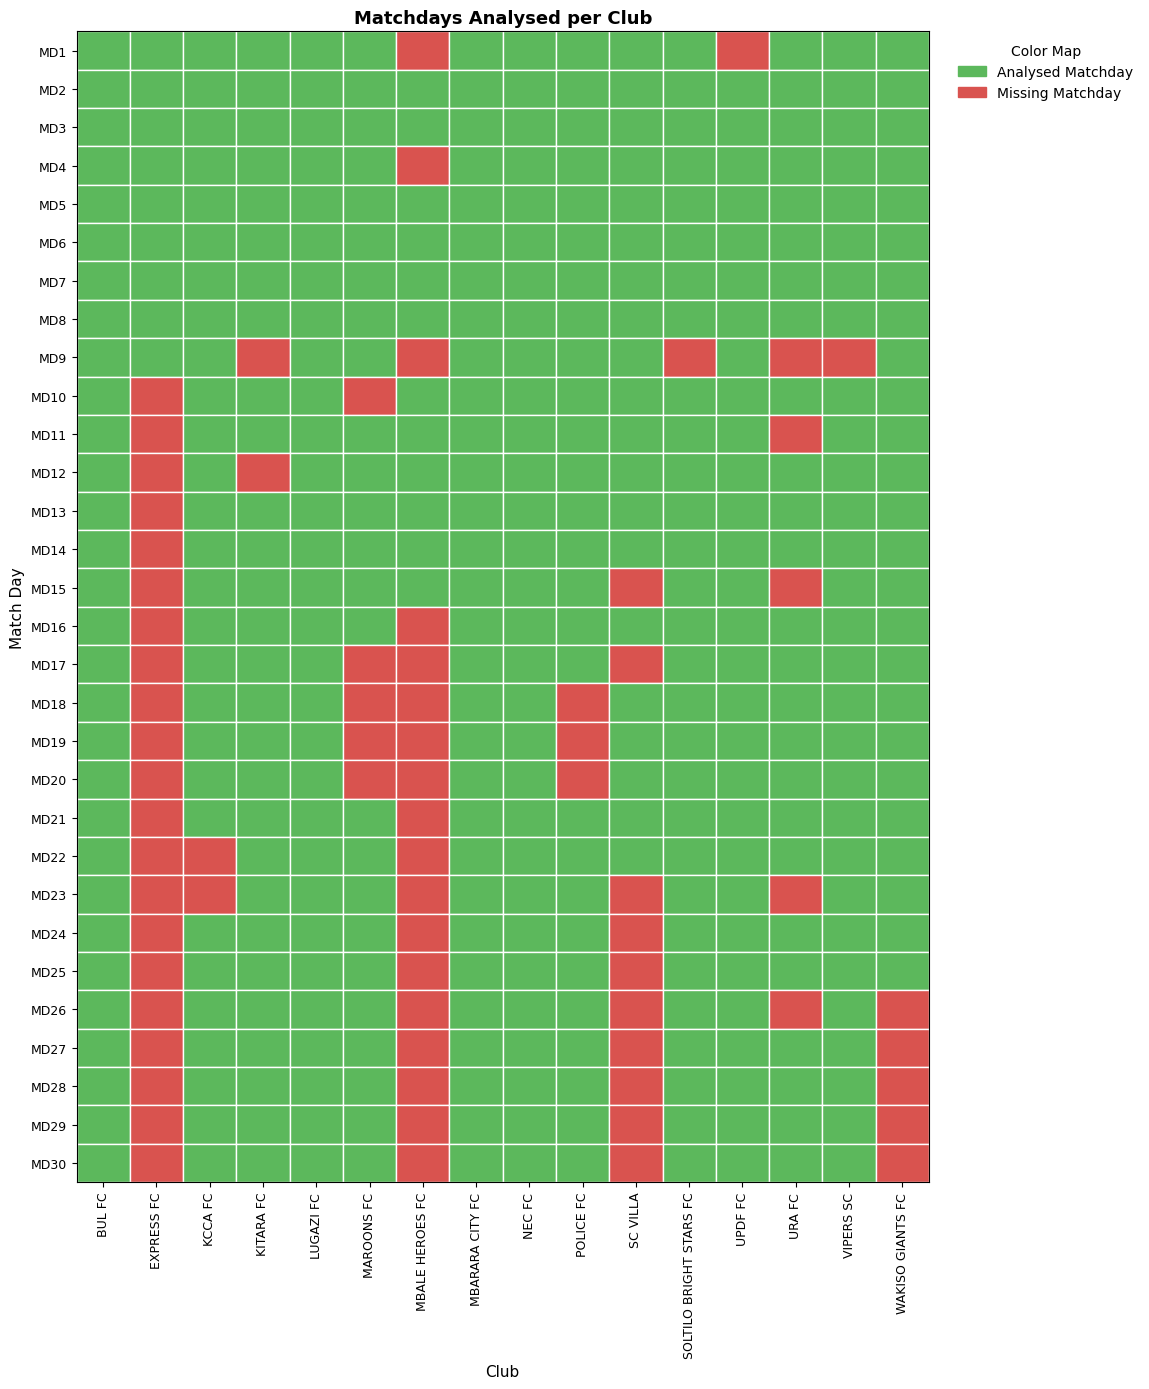

In [17]:

import matplotlib.patches as mpatches

# 1. Get sorted lists of clubs & matchdays
clubs = sorted(df['club_for'].unique())
matchdays = sorted(df['match_day'].unique(), key=lambda x: int(x[2:]) if str(x).startswith('Md') else x)

# 2. Build a binary grid (1 = analysed, 0 = missing)
grid_data = []
for md in matchdays:
    row = []
    for club in clubs:
        mask = (df['match_day'] == md) & (df['club_for'] == club)
        is_present = 1 if df.loc[mask, 'p_name'].nunique() > 0 else 0
        row.append(is_present)
    grid_data.append(row)

# 3. Convert to DataFrame
grid_df = pd.DataFrame(grid_data, index=matchdays, columns=clubs)

# 4. Define colors
color_map = {1: '#5cb85c', 0: '#d9534f'}  # green = uploaded, red = missing

# 5. Plot
fig, ax = plt.subplots(figsize=(len(clubs)*0.6 + 2, len(matchdays)*0.4 + 2))

for y, md in enumerate(matchdays):
    for x, club in enumerate(clubs):
        val = grid_df.loc[md, club]
        color = color_map[val]
        rect = plt.Rectangle((x, y), 1, 1, facecolor=color, edgecolor='white')
        ax.add_patch(rect)

# 6. Axis Labels
ax.set_xticks(np.arange(len(clubs)) + 0.5)
ax.set_xticklabels([c.upper() for c in clubs], rotation=90, fontsize=9)
ax.set_yticks(np.arange(len(matchdays)) + 0.5)
ax.set_yticklabels([i.upper() for i in matchdays], fontsize=9)

ax.set_xlim(0, len(clubs))
ax.set_ylim(0, len(matchdays))
ax.invert_yaxis()

ax.set_xlabel('Club', fontsize=11)
ax.set_ylabel('Match Day', fontsize=11)
ax.set_title('Matchdays Analysed per Club', fontsize=13, fontweight='bold')

# 7. Legend
handles = [
    mpatches.Patch(color=color_map[1], label='Analysed Matchday'),
    mpatches.Patch(color=color_map[0], label='Missing Matchday')
]
ax.legend(handles=handles, title='Color Map', loc='upper left', bbox_to_anchor=(1.02, 1), frameon=False)

plt.tight_layout()
plt.show()


In [18]:
# Calculate total player entries per matchday across all clubs
total_players_per_matchday = df.groupby('match_day')['p_name'].count().reset_index()
total_players_per_matchday.columns = ['match_day', 'total_player_entries']
# Ensure 'match_day' is a categorical variable with the correct order
matchday_order = [f'Md{i}' for i in range(1, 31)]
total_players_per_matchday['match_day'] = pd.Categorical(
    total_players_per_matchday['match_day'],
    categories=matchday_order,
    ordered=True
)
style_table_for_docs(total_players_per_matchday.sort_values(by='match_day'))

,match_day,total_player_entries
0,Md1,118
11,Md2,156
22,Md3,155
24,Md4,148
25,Md5,147
26,Md6,157
27,Md7,165
28,Md8,146
29,Md9,105
1,Md10,135


In [19]:
# Count the number of unique clubs that submitted data per matchday
clubs_per_matchday = df.groupby('match_day')['club_for'].nunique().reset_index()
clubs_per_matchday.columns = ['match_day', 'num_clubs']
# Ensure 'match_day' is a categorical variable with the correct order
matchday_order = [f'Md{i}' for i in range(1, 31)]
clubs_per_matchday['match_day'] = pd.Categorical(
    clubs_per_matchday['match_day'],
    categories=matchday_order,
    ordered=True
)
style_table_for_docs(clubs_per_matchday.sort_values(by='match_day')) 


,match_day,num_clubs
0,Md1,14
11,Md2,16
22,Md3,16
24,Md4,15
25,Md5,16
26,Md6,16
27,Md7,16
28,Md8,16
29,Md9,11
1,Md10,14


In [20]:

def plot_line_with_values(data, x_col, y_col, title=None, x_label=None,y_label=None, figsize=(10, 6)):
    # Create figure and axis
    plt.figure(figsize=figsize)
    
    # Plot the line
    sns.lineplot(data=data, x=x_col, y=y_col, marker='o', color='orange', linewidth=2)    
    # Get current axis
    ax = plt.gca()
    
    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Set spine and tick colors to light gray
    gray_color = '#808080'
    ax.spines['bottom'].set_color(gray_color)
    ax.spines['left'].set_color(gray_color)


    if x_col == 'match_day':
        # Ensure match_day is ordered as per matchday_order
        data[x_col] = pd.Categorical(data[x_col], categories=matchday_order, ordered=True)
        data_sorted = data.sort_values(by=x_col)
        xticklabels = [str(md).replace('Md', 'MD ') for md in data_sorted[x_col]]
        ax.set_xticks(range(len(data_sorted[x_col])))
        ax.set_xticklabels(xticklabels, rotation=90)
        # Re-plot with sorted data to ensure correct order
        
        sns.lineplot(data=data_sorted, x=x_col, y=y_col, marker='o', color='orange', linewidth=2)
        
    # Add value labels above each point
    for i, (x, y) in enumerate(zip(data[x_col], data[y_col])):
        ax.annotate(
            f'{y}', 
            (x, y),
            textcoords="offset points", 
            xytext=(0, 10), 
            ha='center',
            fontsize=8,
            bbox=dict(boxstyle="circle,pad=0.35", edgecolor='#FE912A', facecolor='white', linewidth=1)
        )
    
    # Set title
    if title is None:
        title = f'{y_col} vs {x_col}'
    plt.title(title)

    # #start the y-axis at 0
    # ax.set_ylim(bottom=60,top=180)  # Adjust the top limit as needed

    # Set labels
    if x_label is None:
        x_label = x_col.replace('_', ' ').title()
    plt.xlabel(x_label)
    if y_label is None:
        y_label = y_col.replace('_', ' ').title()
    plt.ylabel(y_label)
    plt.grid(axis='y', linestyle='--', linewidth=0.5, color='#E0DCDD', alpha=0.7)
    # Adjust layout
    plt.tight_layout()
    
    return ax

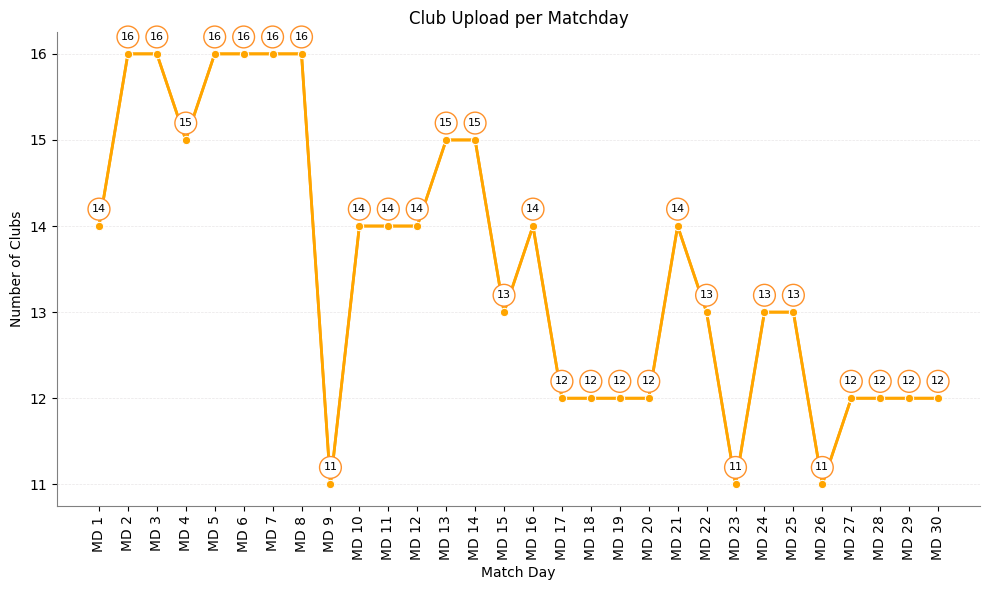

In [21]:
plot_line_with_values(clubs_per_matchday, 'match_day', 'num_clubs', title='Club Upload per Matchday', x_label='Match Day', y_label='Number of Clubs');

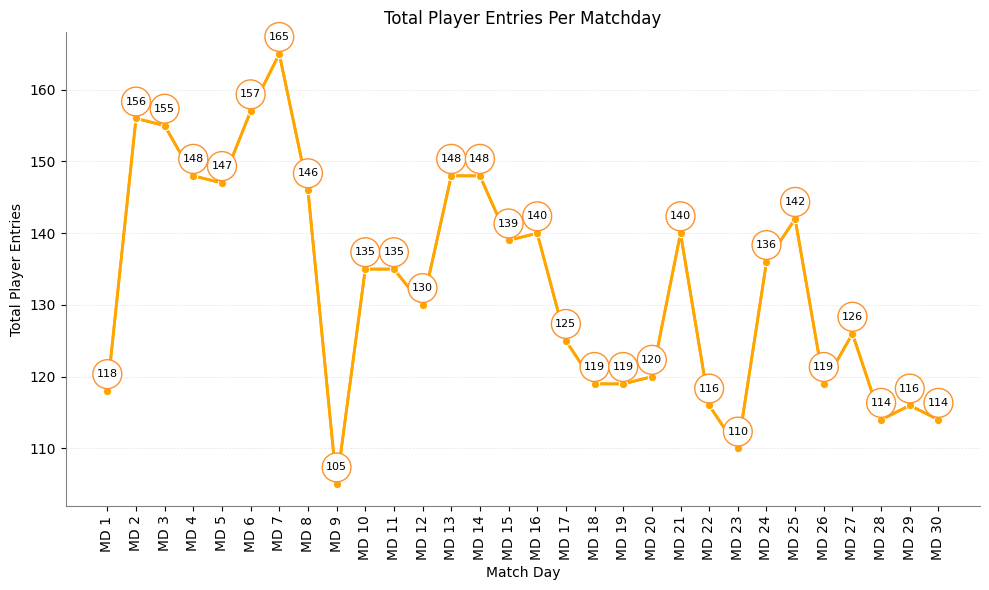

In [22]:
plot_line_with_values(total_players_per_matchday, 'match_day', 'total_player_entries', title='Total Player Entries Per Matchday', x_label='Match Day', y_label='Total Player Entries');

In [23]:
# Count number and percentage of entries based on 'location'
location_counts = df['location'].value_counts().reset_index()
location_counts.columns = ['location', 'count']
location_counts['percentage'] = (location_counts['count'] / len(df)) * 100

style_table_for_docs(location_counts)

,location,count,percentage
0,Away,2053,51.479438
1,Home,1935,48.520562


In [24]:
# Count number and percentage of entries based on 'result'
location_counts = df['result'].value_counts().reset_index()
location_counts.columns = ['result', 'count']
location_counts['percentage'] = (location_counts['count'] / len(df)) * 100

style_table_for_docs(location_counts)

,result,count,percentage
0,Win,1542,38.665998
1,Loss,1347,33.776329
2,Draw,1099,27.557673


In [25]:
# Calculate Win-Draw-Loss counts for each club using unique match days
matchday_results = df.groupby(['club_for', 'match_day'])['result'].first().reset_index()
wld_counts = matchday_results.groupby(['club_for', 'result']).size().unstack(fill_value=0)
wld_counts = wld_counts[['Win', 'Draw', 'Loss']]  # Ensure order if all present

style_table_for_docs(wld_counts.sort_values(by='Win', ascending=False))


result,Win,Draw,Loss
club_for,,,
Vipers Sc,20,6,3
Nec Fc,19,6,5
Bul Fc,15,11,4
Ura Fc,14,2,9
Kcca Fc,13,8,7
Maroons Fc,11,5,9
Kitara Fc,10,9,9
Mbarara City Fc,9,8,13
Updf Fc,9,8,12


### Max Metrics

In [26]:
speed_table = df[['top_speed_kmh','distance_per_min_mmin','max_acceleration_mss','max_deceleration_mss']].agg(['max', 'mean', 'std']).T
style_table_for_docs(speed_table)

,max,mean,std
top_speed_kmh,36.416300,29.585420,2.302961
distance_per_min_mmin,136.524291,86.752794,24.920299
max_acceleration_mss,10.000000,5.848939,0.627963
max_deceleration_mss,10.000000,7.156942,0.973882


In [27]:
distance_speed_zones = ['distance_in_speed_zone_1_km', 'distance_in_speed_zone_2_km', 'distance_in_speed_zone_3_km','distance_in_speed_zone_4_km','distance_in_speed_zone_5_km']
for i in distance_speed_zones:
    df[i] = df[i] * 1000  # Convert from km to m

speed_zone_dist= df[distance_speed_zones].agg(['sum','max', 'mean', 'std']).T.round(2)
style_table_for_docs(speed_zone_dist)

,sum,max,mean,std
distance_in_speed_zone_1_km,3338389.400000,2099.000000,837.110000,245.120000
distance_in_speed_zone_2_km,16567234.200000,6290.400000,4154.270000,1222.190000
distance_in_speed_zone_3_km,10652057.800000,6135.200000,2671.030000,1000.770000
distance_in_speed_zone_4_km,2910061.400000,2349.500000,729.700000,316.840000
distance_in_speed_zone_5_km,453960.800000,643.600000,113.830000,93.940000


## Analysis

### Club Comparison

In [28]:
club_metrics_mean = (
    df.groupby(['club_for', 'match_day'],observed=False)[volume_metrics+intensity_metrics].mean()
    .groupby('club_for').mean()
    .rename(columns=lambda x: f'avg_{x}')
    .sort_values(by='avg_distance_km', ascending=False)
    .reset_index()
)
style_table_for_docs(club_metrics_mean.round(2))


,club_for,avg_distance_km,avg_sprint_distance_m,avg_power_plays,avg_energy_kcal,avg_impacts,avg_total_accelerations,avg_total_decelerations,avg_player_load,avg_top_speed_kmh,avg_distance_per_min_mmin,avg_power_score_wkg,avg_work_ratio,avg_max_acceleration_mss,avg_max_deceleration_mss,avg_acc_counts_per_min,avg_dec_counts_per_min
0,Sc Villa,10.140000,1106.300000,72.800000,1228.880000,7.300000,448.600000,427.370000,455.930000,30.440000,103.710000,16.700000,89.390000,5.930000,7.500000,4.590000,4.370000
1,Soltilo Bright Stars Fc,9.680000,853.280000,64.530000,1161.130000,7.760000,445.920000,431.160000,452.040000,29.250000,98.610000,15.690000,81.700000,5.830000,7.390000,4.540000,4.390000
2,Kcca Fc,9.080000,996.970000,69.680000,1112.520000,5.900000,426.670000,408.450000,406.890000,30.430000,91.870000,14.940000,78.470000,5.900000,7.250000,4.320000,4.130000
3,Maroons Fc,8.990000,975.170000,67.970000,1106.800000,4.700000,419.140000,403.480000,410.130000,29.740000,92.390000,14.930000,78.300000,5.790000,7.180000,4.310000,4.150000
4,Vipers Sc,8.890000,915.560000,65.020000,1086.180000,8.110000,413.900000,395.910000,410.330000,30.500000,88.550000,14.350000,72.040000,5.970000,7.240000,4.130000,3.950000
5,Bul Fc,8.790000,768.210000,57.250000,1110.840000,5.840000,417.840000,398.850000,401.960000,29.570000,88.270000,14.110000,72.760000,5.920000,7.120000,4.190000,4.000000
6,Express Fc,8.790000,876.270000,63.720000,1094.130000,6.890000,443.810000,425.070000,418.720000,29.310000,87.570000,14.280000,73.510000,5.860000,7.240000,4.420000,4.240000
7,Police Fc,8.610000,804.900000,58.160000,1064.600000,6.860000,406.450000,391.560000,395.330000,29.320000,86.850000,13.930000,70.860000,5.950000,7.150000,4.100000,3.950000
8,Ura Fc,8.540000,881.900000,61.740000,1040.490000,5.470000,406.740000,390.820000,391.890000,29.770000,86.980000,13.990000,72.360000,5.930000,7.020000,4.140000,3.980000
9,Lugazi Fc,8.420000,806.200000,58.880000,1023.590000,6.410000,393.490000,376.200000,383.000000,29.400000,85.850000,13.820000,72.080000,5.760000,7.310000,4.010000,3.840000


In [29]:
team_avg_dist_per_match = (
    df
    .groupby(['club_for', 'match_day'], observed=False)['distance_km']
    .sum()  # Total team distance on a match day
    .groupby('club_for')
    .mean()  # Average total team distance per match across all match days
    .reset_index(name='avg_team_distance_per_match_km')
    .sort_values(by='avg_team_distance_per_match_km', ascending=False)
)
style_table_for_docs(team_avg_dist_per_match)

,club_for,avg_team_distance_per_match_km
5,Maroons Fc,99.686940
13,Ura Fc,92.845512
7,Mbarara City Fc,92.521230
15,Wakiso Giants Fc,91.588260
4,Lugazi Fc,91.387633
1,Express Fc,89.531489
3,Kitara Fc,87.058832
14,Vipers Sc,86.687697
2,Kcca Fc,85.767354
8,Nec Fc,83.014767


In [30]:
club_intensity_max = (
    df.groupby('club_for')[['top_speed_kmh', 'distance_per_min_mmin']]
    .max()
    .rename(columns=lambda x: f'max_{x}')
    .sort_values(by='max_top_speed_kmh', ascending=False)
    .reset_index()
)
style_table_for_docs(club_intensity_max.round(2))

,club_for,max_top_speed_kmh,max_distance_per_min_mmin
0,Bul Fc,36.420000,124.300000
1,Ura Fc,36.220000,128.650000
2,Lugazi Fc,36.210000,126.420000
3,Nec Fc,36.020000,129.710000
4,Sc Villa,36.020000,136.520000
5,Vipers Sc,35.840000,121.880000
6,Mbarara City Fc,35.730000,124.950000
7,Kcca Fc,35.570000,126.310000
8,Kitara Fc,35.300000,124.070000
9,Maroons Fc,35.140000,128.550000


In [31]:
club_intensity_avg = (
    df.groupby('club_for')[['top_speed_kmh', 'distance_per_min_mmin']]
    .mean()
    .rename(columns=lambda x: f'avg_{x}')
    .sort_values(by='avg_top_speed_kmh', ascending=False)
    .reset_index()
)
style_table_for_docs(club_intensity_avg.round(2))

,club_for,avg_top_speed_kmh,avg_distance_per_min_mmin
0,Sc Villa,30.430000,103.700000
1,Vipers Sc,30.430000,87.150000
2,Kcca Fc,30.390000,91.230000
3,Kitara Fc,29.720000,83.440000
4,Maroons Fc,29.720000,91.660000
5,Ura Fc,29.690000,84.550000
6,Updf Fc,29.670000,82.200000
7,Bul Fc,29.510000,86.190000
8,Nec Fc,29.460000,82.800000
9,Lugazi Fc,29.390000,84.530000


### Metric High Scores

In [32]:
# For each metric in volume_metrics, find the player with the highest value, the value, and the club
top_players = []
for metric in volume_metrics +intensity_metrics:
    idx = df[metric].idxmax()
    row = df.loc[idx]
    top_players.append({
        'metric': metric,
        'player': row['p_name'],
        'club': row['club_for'],
        'value': row[metric],
        'match day': row['match_day']
    })

top_players_df = pd.DataFrame(top_players)
style_table_for_docs(top_players_df)

,metric,player,club,value,match day
0,distance_km,Ronald Ssekiganda,Sc Villa,13.499000,Md7
1,sprint_distance_m,Innocent Wafula Esimu,Mbarara City Fc,2894.443000,Md1
2,power_plays,Innocent Wafula Esimu,Mbarara City Fc,145.000000,Md1
3,energy_kcal,Amos Etoju,Mbale Heroes Fc,1771.047900,Md11
4,impacts,Blanchar Mulamba,Wakiso Giants Fc,46.000000,Md13
5,total_accelerations,Felix Okot,Maroons Fc,705.000000,Md29
6,total_decelerations,Richard Okello,Bul Fc,667.000000,Md16
7,player_load,Felix Okot,Maroons Fc,655.960600,Md29
8,top_speed_kmh,Yafeesi Mubiru,Bul Fc,36.416300,Md11
9,distance_per_min_mmin,Ronald Ssekiganda,Sc Villa,136.524291,Md1


### Comparison by Position Group

In [33]:
# Calculate average volume metrics by general position
avg_volume_by_position = df.groupby('general_position')[volume_metrics].mean().round(2)
style_table_for_docs(avg_volume_by_position)

,distance_km,sprint_distance_m,power_plays,energy_kcal,impacts,total_accelerations,total_decelerations
general_position,,,,,,,
Defender,9.030000,845.890000,59.830000,1111.270000,6.030000,429.520000,412.440000
Forward,7.560000,874.850000,58.110000,928.410000,7.410000,336.120000,323.140000
Midfielder,8.660000,814.710000,62.450000,1050.070000,5.680000,409.060000,391.900000


In [34]:
# Calculate average intensity metrics by general position
avg_intensity_by_position = df.groupby('general_position')[[i for i in intensity_metrics if i not in ['top_speed_kmh','distance_per_min_mmin','max_acceleration_mss','max_deceleration_mss']]].mean()
style_table_for_docs(avg_intensity_by_position)

,player_load,power_score_wkg,work_ratio,acc_counts_per_min,dec_counts_per_min
general_position,,,,,
Defender,414.911731,14.752548,77.056381,4.369812,4.196008
Forward,350.113184,12.549012,61.998511,3.440950,3.308696
Midfielder,396.516519,14.177292,75.505109,4.174668,3.999559


In [35]:
# Calculate max metrics by general position
avg_intensity_by_position_ = df.groupby('general_position')[['top_speed_kmh','distance_per_min_mmin','acc_counts_per_min','dec_counts_per_min']].max().round(2)
style_table_for_docs(avg_intensity_by_position_)

,top_speed_kmh,distance_per_min_mmin,acc_counts_per_min,dec_counts_per_min
general_position,,,,
Defender,35.840000,127.680000,6.600000,6.490000
Forward,36.420000,127.680000,6.270000,6.150000
Midfielder,36.220000,136.520000,7.110000,6.710000


In [36]:
# Calculate mean max metrics by general position
avg_intensity_by_position_ = df.groupby('general_position')[['top_speed_kmh','distance_per_min_mmin','acc_counts_per_min','dec_counts_per_min']].mean().round(2)
style_table_for_docs(avg_intensity_by_position_)

,top_speed_kmh,distance_per_min_mmin,acc_counts_per_min,dec_counts_per_min
general_position,,,,
Defender,29.830000,91.910000,4.370000,4.200000
Forward,30.550000,77.380000,3.440000,3.310000
Midfielder,28.500000,88.390000,4.170000,4.000000


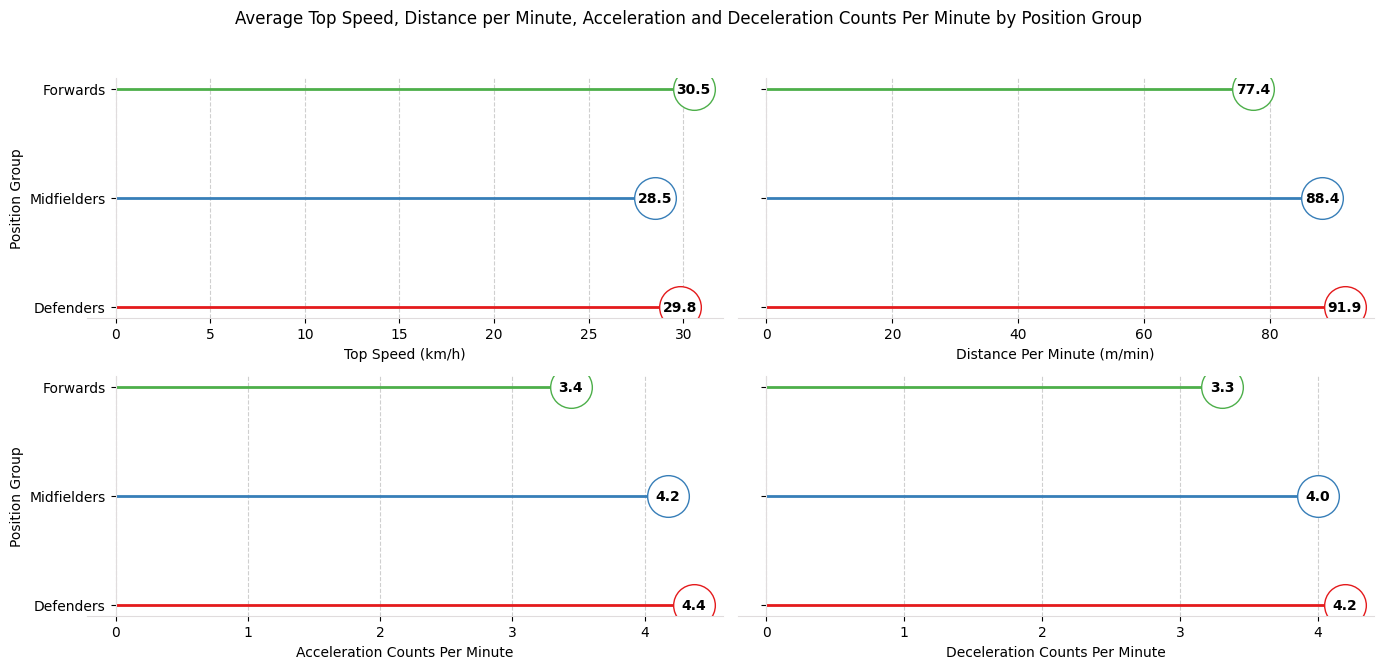

In [37]:
# Draw thin horizontal lines with a large circle at the end for each position group, for four metrics in a 2x2 grid

metrics_to_plot = [
    ('top_speed_kmh', 'Top Speed (km/h)'),
    ('distance_per_min_mmin', 'Distance Per Minute (m/min)'),
    ('acc_counts_per_min', 'Acceleration Counts Per Minute'),
    ('dec_counts_per_min', 'Deceleration Counts Per Minute')
]

# Define the order of position groups
position_order = ['Defender', 'Midfielder', 'Forward']

fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharey=True)

for ax, (metric, xlabel) in zip(axes.flatten(), metrics_to_plot):
    avg_by_position = df.groupby('general_position')[metric].mean().reindex(position_order)
    n = len(avg_by_position)
    y_positions = np.arange(n)
    palette = sns.color_palette('Set1', n)
    circle_radius = 30

    for y, (pos, val), color in zip(y_positions, avg_by_position.items(), palette):
        ax.hlines(y=y, xmin=0, xmax=val, color=color, linewidth=2)
        ax.plot(val, y, 'o', markeredgecolor=color, markersize=circle_radius, markerfacecolor='white')
        if metric == 'top_speed_kmh':
            text_val = f'{val:.1f}'
        elif metric == 'distance_per_min_mmin':
            text_val = f'{val:.1f}'
        elif metric == 'acc_counts_per_min':
            text_val = f'{val:.1f}'
        else:
            text_val = f'{val:.1f}'
        ax.text(val, y, text_val, va='center', ha='center', fontsize=10, color='black', fontweight='bold')

    yticklabels = [f"{pos}s" for pos in position_order]
    ax.set_yticks(y_positions)
    ax.set_yticklabels(yticklabels, color='#E0DCDD')
    ax.set_xlabel(xlabel)
    ax.grid(axis='x', linestyle='--', alpha=0.6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_position(('data', 0))
    ax.spines['left'].set_color('#E0DCDD')
    ax.spines['bottom'].set_color('#E0DCDD')

axes[0,0].set_ylabel('Position Group')
axes[1,0].set_ylabel('Position Group')
fig.suptitle('Average Top Speed, Distance per Minute, Acceleration and Deceleration Counts Per Minute by Position Group')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


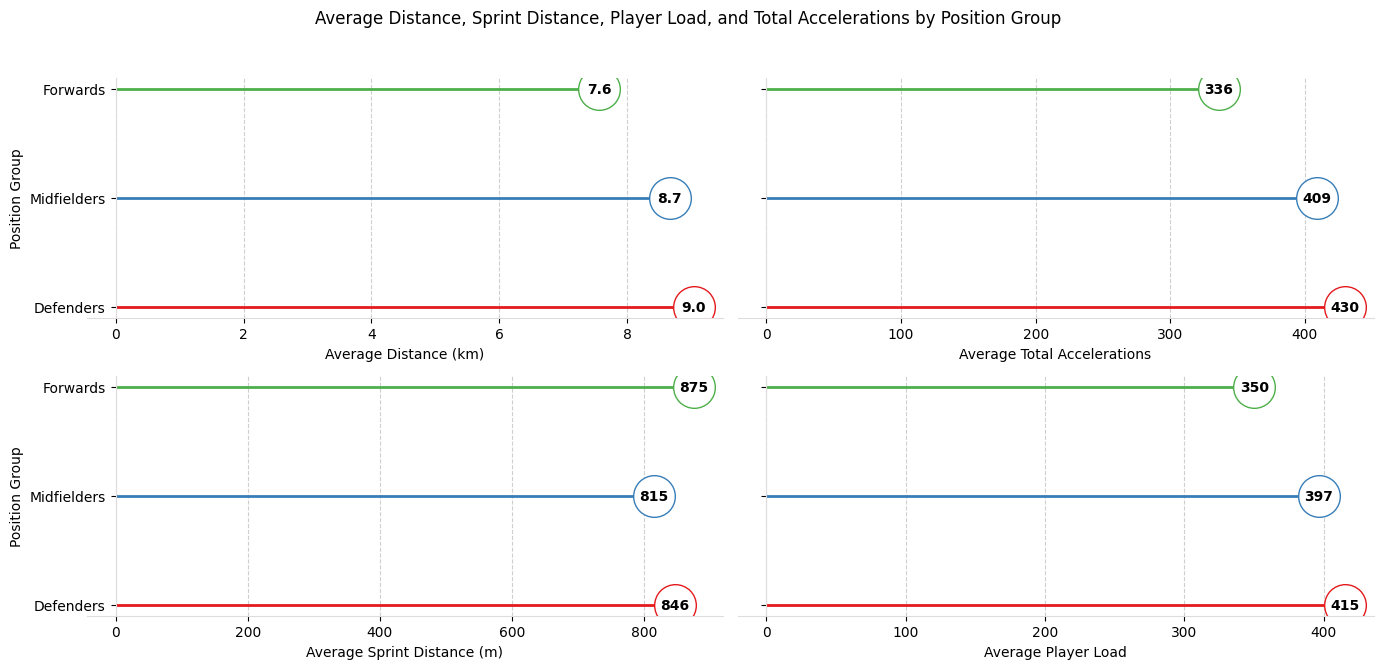

In [38]:
# Draw thin horizontal lines with a large circle at the end for each position group, for four metrics in a 2x2 grid

metrics_to_plot = [
    ('distance_km', 'Average Distance (km)'),
    ('total_accelerations', 'Average Total Accelerations'),
    ('sprint_distance_m', 'Average Sprint Distance (m)'),
    ('player_load', 'Average Player Load')
]

# Define the order of position groups
position_order = ['Defender', 'Midfielder', 'Forward']

fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharey=True)

for ax, (metric, xlabel) in zip(axes.flatten(), metrics_to_plot):
    avg_by_position = df.groupby('general_position')[metric].mean().reindex(position_order)
    n = len(avg_by_position)
    y_positions = np.arange(n)
    palette = sns.color_palette('Set1', n)
    circle_radius = 30

    for y, (pos, val), color in zip(y_positions, avg_by_position.items(), palette):
        ax.hlines(y=y, xmin=0, xmax=val, color=color, linewidth=2)
        ax.plot(val, y, 'o', markeredgecolor=color, markersize=circle_radius, markerfacecolor='white')
        if metric == 'distance_km':
            text_val = f'{val:.1f}'
        elif metric == 'sprint_distance_m':
            text_val = f'{val:.0f}'
        elif metric == 'player_load':
            text_val = f'{val:.0f}'
        else:
            text_val = f'{val:.0f}'
        ax.text(val, y, text_val, va='center', ha='center', fontsize=10, color='black', fontweight='bold')

    yticklabels = [f"{pos}s" for pos in position_order]
    ax.set_yticks(y_positions)
    ax.set_yticklabels(yticklabels, color='#E0DCDD')
    ax.set_xlabel(xlabel)
    ax.grid(axis='x', linestyle='--', alpha=0.6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_position(('data', 0))
    ax.spines['left'].set_color('#E0DCDD')
    ax.spines['bottom'].set_color('#E0DCDD')

axes[0,0].set_ylabel('Position Group')
axes[1,0].set_ylabel('Position Group')
fig.suptitle('Average Distance, Sprint Distance, Player Load, and Total Accelerations by Position Group')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


### Comparison by Location

In [39]:
# Calculate average volume metrics by location
avg_volume_by_location = df.groupby('location')[volume_metrics].mean().round(2)
style_table_for_docs(avg_volume_by_location)

,distance_km,sprint_distance_m,power_plays,energy_kcal,impacts,total_accelerations,total_decelerations
location,,,,,,,
Away,8.500000,838.250000,60.150000,1039.900000,6.260000,398.350000,382.370000
Home,8.520000,849.150000,60.300000,1041.710000,6.330000,395.740000,379.760000


In [40]:
# Calculate average intensity metrics by location
avg_intensity_by_location = df.groupby('location')[[i for i in intensity_metrics if i not in ['top_speed_kmh','distance_per_min_mmin','max_acceleration_mss','max_deceleration_mss']]].mean()
style_table_for_docs(avg_intensity_by_location)

,player_load,power_score_wkg,work_ratio,acc_counts_per_min,dec_counts_per_min
location,,,,,
Away,391.041936,13.935497,72.402723,4.058301,3.895639
Home,390.995553,13.979198,72.407495,4.041185,3.878202


In [41]:
# Calculate max metrics by location
avg_intensity_by_location_ = df.groupby('location')[['top_speed_kmh','distance_per_min_mmin']].mean().round(2)
style_table_for_docs(avg_intensity_by_location_)

,top_speed_kmh,distance_per_min_mmin
location,,
Away,29.540000,86.570000
Home,29.630000,86.950000


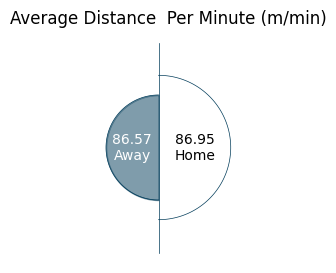

In [42]:
# Prepare data
home_speed = avg_intensity_by_location_.loc['Home', 'distance_per_min_mmin']
away_speed = avg_intensity_by_location_.loc['Away', 'distance_per_min_mmin']

# Make radius proportional to top speed (e.g., scale so max speed gets max_radius, min gets min_radius)
min_radius = 0.8
max_radius = 1.1
speeds = np.array([home_speed, away_speed])
norm_radii = min_radius + (speeds - speeds.min()) / (speeds.max() - speeds.min()) * (max_radius - min_radius)
home_radius, away_radius = norm_radii

color = '#003b59'

fig, ax = plt.subplots(figsize=(3, 3))
ax.set_aspect('equal')
ax.axis('off')

# Draw right (Home) semicircle: theta from -pi/2 to pi/2, center at (0,0)
theta_home = np.linspace(-np.pi/2, np.pi/2, 100)
x_home = home_radius * np.cos(theta_home)
y_home = home_radius * np.sin(theta_home)
ax.plot(x_home, y_home, color=color, linewidth=0.5)
if home_radius < away_radius:
    ax.fill_betweenx(y_home, 0, x_home, color=color, alpha=0.5)

# Draw left (Away) semicircle: theta from pi/2 to 3pi/2, center at (0,0)
theta_away = np.linspace(np.pi/2, 3*np.pi/2, 100)
x_away = away_radius * np.cos(theta_away)
y_away = away_radius * np.sin(theta_away)
ax.plot(x_away, y_away, color=color, linewidth=0.5)
if away_radius < home_radius:
    ax.fill_betweenx(y_away, x_away, 0, color=color, alpha=0.5)

# Draw the separating line (y from -max_radius to +max_radius at x=0)
ax.plot([0, 0], [-max(home_radius+0.5, away_radius+0.5), max(home_radius+0.5, away_radius+0.5)], color=color, linewidth=0.5, zorder=3)

# Place values inside semicircles, centered
ax.text(home_radius * 0.5, 0, f"{home_speed:.2f}\nHome", ha='center', va='center', fontsize=10, color='#000', fontweight='normal')
ax.text(-away_radius * 0.5, 0, f"{away_speed:.2f}\nAway", ha='center', va='center', fontsize=10, color='#fff', fontweight='normal')

plt.title('Average Distance  Per Minute (m/min)', fontsize=12)
plt.show()


### Metric Distribution 

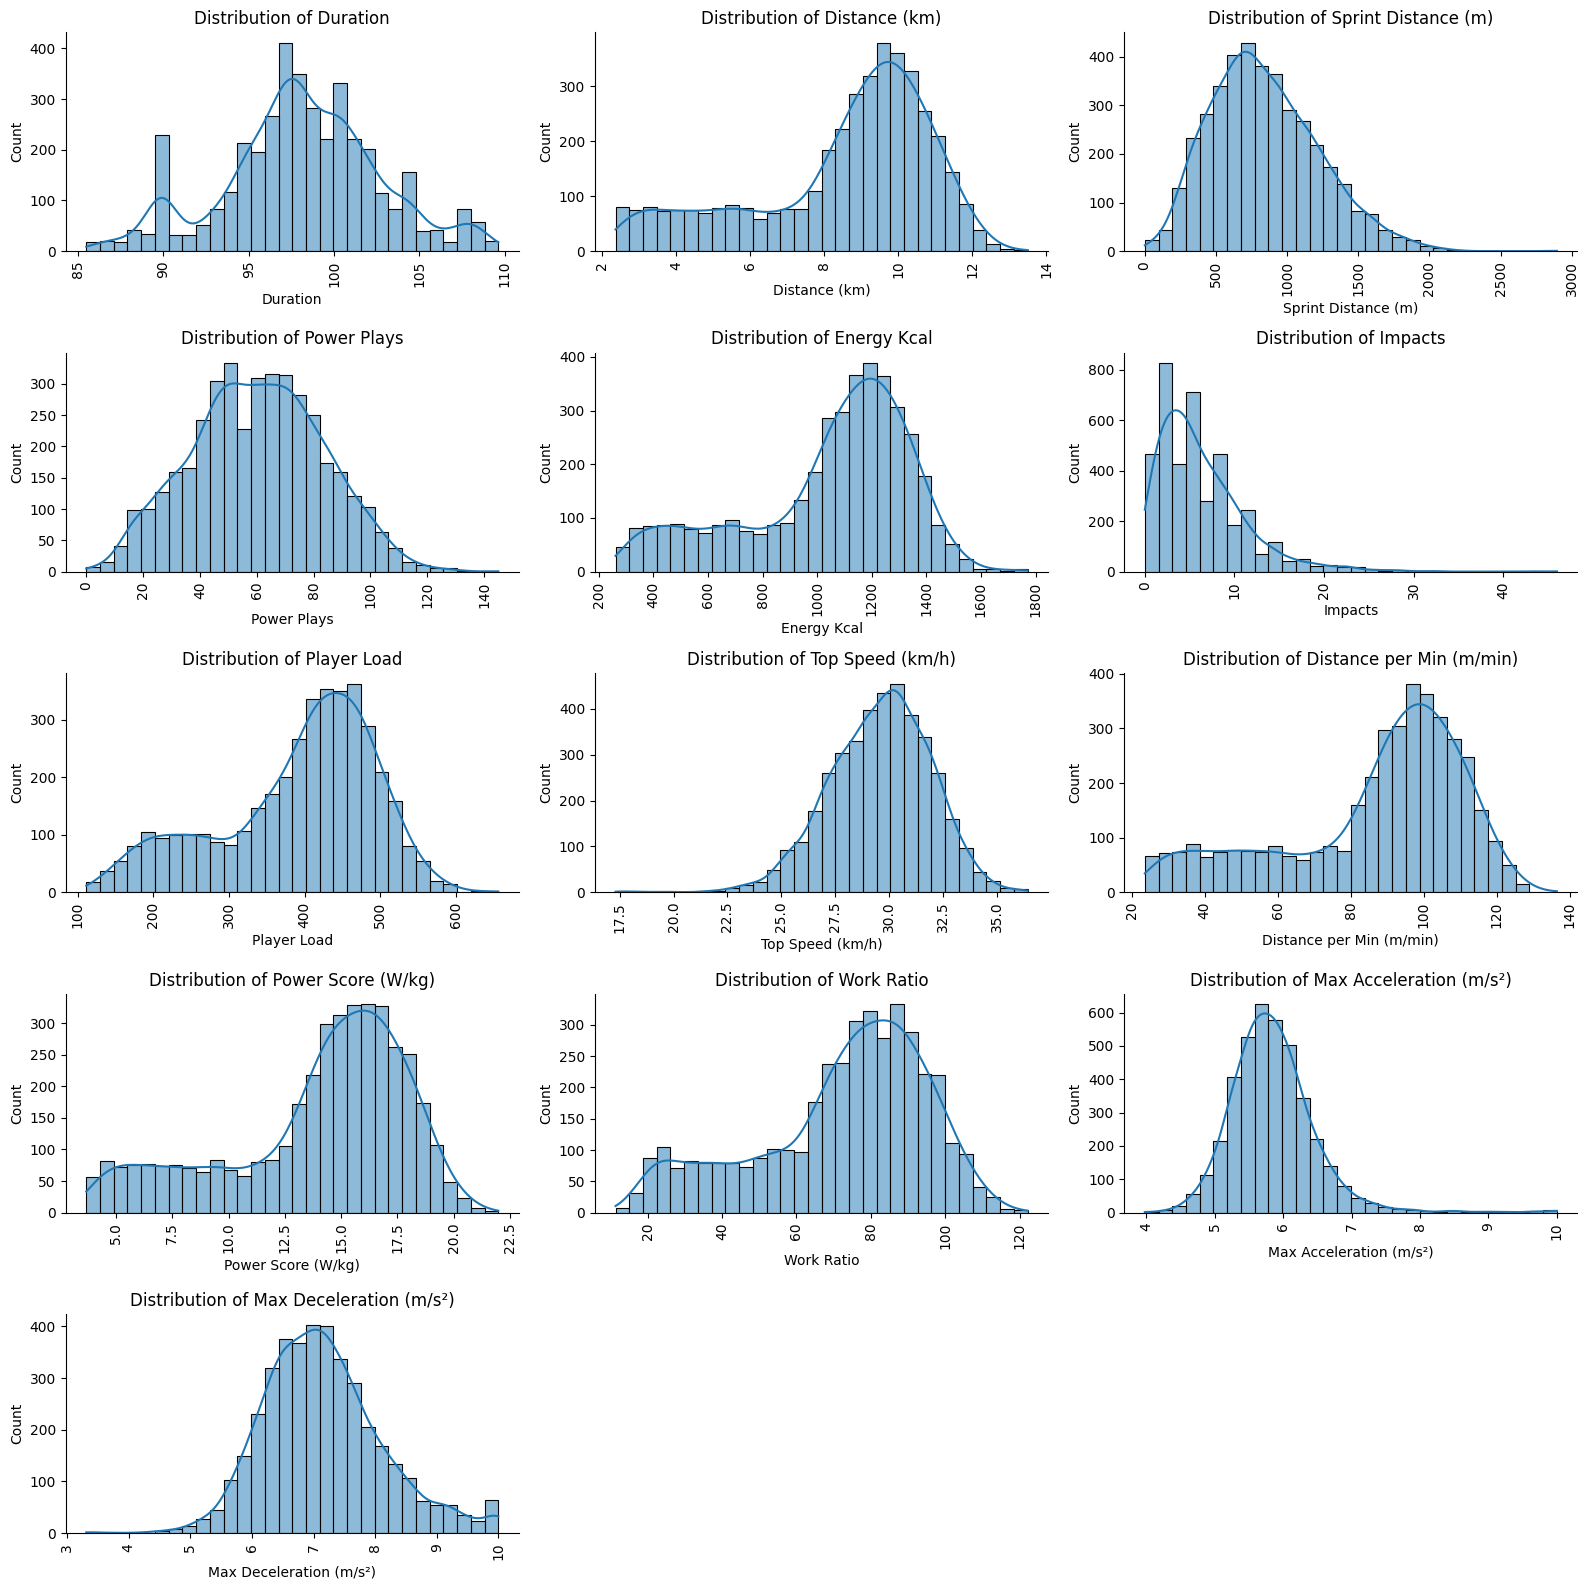

In [43]:
plt.figure(figsize=(16, 16))
for i, col in enumerate(num_cols):
    plt.subplot(5, 3, i + 1)
    sns.histplot(df[col], bins=30, kde=True)
    # Format title and x-label: replace _ with space, capitalize, add units if present
    label = col.replace('_', ' ').title()
    # Add units for specific columns
    if col == 'distance_km':
        label = 'Distance (km)'
    elif col == 'sprint_distance_m':
        label = 'Sprint Distance (m)'
    elif col == 'top_speed_kmh':
        label = 'Top Speed (km/h)'
    elif col == 'distance_per_min_mmin':
        label = 'Distance per Min (m/min)'
    elif col == 'power_score_wkg':
        label = 'Power Score (W/kg)'
    elif col == 'max_acceleration_mss':
        label = 'Max Acceleration (m/s²)'
    elif col == 'max_deceleration_mss':
        label = 'Max Deceleration (m/s²)'
    elif col == 'acc_counts_per_min':
        label = 'Acc. Counts per Min'
    elif col == 'dec_counts_per_min':
        label = 'Dec. Counts per Min'
    
    plt.title(f'Distribution of {label}')
    plt.xlabel(label)
    plt.xticks(rotation=90)
    # Remove top and right spines
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()



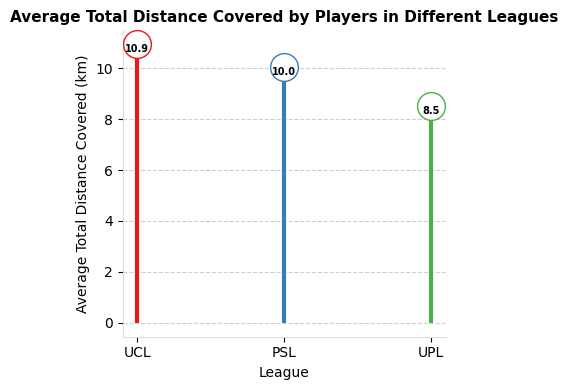

In [44]:
# Comparative bar graph for three leagues using vertical lines with large circles on top

leagues = [ 'UCL','PSL', 'UPL']
values = [ 10.94,10.045, df['distance_km'].mean()]
palette = sns.color_palette('Set1', len(leagues))
circle_radius = 20

fig, ax = plt.subplots(figsize=(4, 4))

# Draw vertical lines for each league
for i, (league, val, color) in enumerate(zip(leagues, values, palette)):
    ax.vlines(i, 0, val, color=color, linewidth=3, zorder=2)
    ax.plot(i, val, 'o', markeredgecolor=color, markerfacecolor='white', markersize=circle_radius, zorder=3)
    ax.text(i, val, f'{val:.1f}', va='top', ha='center', fontweight='bold',fontsize=7, color='black')

ax.set_xticks(range(len(leagues)))
ax.set_xticklabels(leagues)
ax.set_ylabel('Average Total Distance Covered (km)')
ax.set_xlabel('League')
ax.set_title('Average Total Distance Covered by Players in Different Leagues', fontsize=11, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#E0DCDD')
ax.spines['bottom'].set_color('#E0DCDD')
ax.grid(axis='y', linestyle='--', alpha=0.6, zorder=1)
plt.tight_layout()
plt.show()

## Trend Analysis

In [45]:
avg_volume_per_matchday = df.groupby('match_day')[volume_metrics + intensity_metrics].mean().reset_index()
# Ensure 'match_day' is a categorical variable with the correct order
avg_volume_per_matchday['match_day'] = pd.Categorical(
    avg_volume_per_matchday['match_day'],
    categories=matchday_order,
    ordered=True
)
avg_volume_per_matchday = avg_volume_per_matchday.sort_values(by='match_day').round(2)
style_table_for_docs(avg_volume_per_matchday)

,match_day,distance_km,sprint_distance_m,power_plays,energy_kcal,impacts,total_accelerations,total_decelerations,player_load,top_speed_kmh,distance_per_min_mmin,power_score_wkg,work_ratio,max_acceleration_mss,max_deceleration_mss,acc_counts_per_min,dec_counts_per_min
0,Md1,9.030000,955.200000,67.310000,1109.370000,7.030000,425.750000,408.530000,416.080000,29.600000,91.570000,14.860000,77.300000,5.920000,7.270000,4.320000,4.140000
11,Md2,8.810000,938.360000,65.590000,1075.160000,6.530000,404.280000,388.540000,404.600000,29.890000,89.650000,14.490000,74.610000,5.920000,7.140000,4.110000,3.950000
22,Md3,8.940000,861.720000,62.440000,1089.390000,6.540000,428.580000,412.070000,412.730000,29.760000,89.700000,14.430000,75.280000,5.880000,7.180000,4.310000,4.140000
24,Md4,8.710000,849.410000,61.060000,1064.950000,7.140000,417.190000,401.170000,401.100000,29.680000,88.030000,14.230000,73.770000,5.830000,7.170000,4.220000,4.060000
25,Md5,9.030000,904.580000,65.560000,1108.020000,6.890000,435.030000,418.340000,416.540000,29.600000,91.650000,14.800000,77.160000,5.840000,7.080000,4.410000,4.250000
26,Md6,8.560000,815.960000,57.620000,1043.400000,6.160000,395.710000,378.770000,394.570000,29.650000,86.820000,13.850000,72.390000,5.920000,7.230000,4.010000,3.840000
27,Md7,8.450000,827.720000,59.480000,1035.590000,5.850000,391.950000,376.180000,386.720000,29.520000,84.730000,13.610000,70.890000,5.820000,7.330000,3.930000,3.770000
28,Md8,8.670000,897.870000,62.630000,1064.690000,6.840000,407.530000,391.380000,399.250000,29.730000,86.950000,14.050000,72.380000,5.780000,7.350000,4.080000,3.920000
29,Md9,8.810000,887.070000,61.410000,1080.680000,6.410000,414.520000,396.860000,400.430000,29.540000,89.270000,14.380000,74.040000,5.730000,7.140000,4.200000,4.020000
1,Md10,8.630000,824.730000,61.610000,1060.760000,6.610000,411.660000,395.730000,396.620000,29.570000,88.670000,14.330000,74.180000,5.870000,7.220000,4.230000,4.070000


In [46]:
# Sort by match_day using the correct order
df['match_day'] = pd.Categorical(df['match_day'], categories=matchday_order, ordered=True)
df_sorted = df.sort_values('match_day')

# Compute rolling mean for each metric per match day
rolling_avg = (
    df_sorted.groupby('match_day', observed=True)[volume_metrics + intensity_metrics]
    .mean()
    .rolling(window=3, min_periods=1)
    .mean()
    .reset_index()
)

rolling_avg['match_day'] = pd.Categorical(rolling_avg['match_day'], categories=matchday_order, ordered=True)
rolling_avg = rolling_avg.sort_values(by='match_day').round(2)
style_table_for_docs(rolling_avg)

,match_day,distance_km,sprint_distance_m,power_plays,energy_kcal,impacts,total_accelerations,total_decelerations,player_load,top_speed_kmh,distance_per_min_mmin,power_score_wkg,work_ratio,max_acceleration_mss,max_deceleration_mss,acc_counts_per_min,dec_counts_per_min
0,Md1,9.030000,955.200000,67.310000,1109.370000,7.030000,425.750000,408.530000,416.080000,29.600000,91.570000,14.860000,77.300000,5.920000,7.270000,4.320000,4.140000
1,Md2,8.920000,946.780000,66.450000,1092.270000,6.780000,415.020000,398.540000,410.340000,29.740000,90.610000,14.680000,75.950000,5.920000,7.210000,4.210000,4.050000
2,Md3,8.930000,918.430000,65.110000,1091.310000,6.700000,419.540000,403.050000,411.130000,29.750000,90.300000,14.590000,75.730000,5.910000,7.200000,4.250000,4.080000
3,Md4,8.820000,883.160000,63.030000,1076.500000,6.730000,416.680000,400.590000,406.140000,29.780000,89.120000,14.380000,74.560000,5.880000,7.170000,4.210000,4.050000
4,Md5,8.890000,871.900000,63.020000,1087.460000,6.860000,426.930000,410.530000,410.120000,29.680000,89.790000,14.490000,75.400000,5.850000,7.150000,4.310000,4.150000
5,Md6,8.770000,856.650000,61.420000,1072.130000,6.730000,415.970000,399.430000,404.070000,29.640000,88.840000,14.290000,74.440000,5.860000,7.160000,4.210000,4.050000
6,Md7,8.680000,849.420000,60.890000,1062.340000,6.300000,407.560000,391.100000,399.280000,29.590000,87.740000,14.090000,73.480000,5.860000,7.210000,4.120000,3.950000
7,Md8,8.560000,847.180000,59.910000,1047.900000,6.290000,398.390000,382.110000,393.520000,29.630000,86.170000,13.840000,71.880000,5.840000,7.300000,4.010000,3.840000
8,Md9,8.650000,870.890000,61.170000,1060.320000,6.370000,404.670000,388.140000,395.470000,29.600000,86.980000,14.010000,72.440000,5.780000,7.270000,4.070000,3.900000
9,Md10,8.700000,869.890000,61.880000,1068.710000,6.620000,411.240000,394.660000,398.770000,29.620000,88.300000,14.250000,73.530000,5.790000,7.230000,4.170000,4.000000


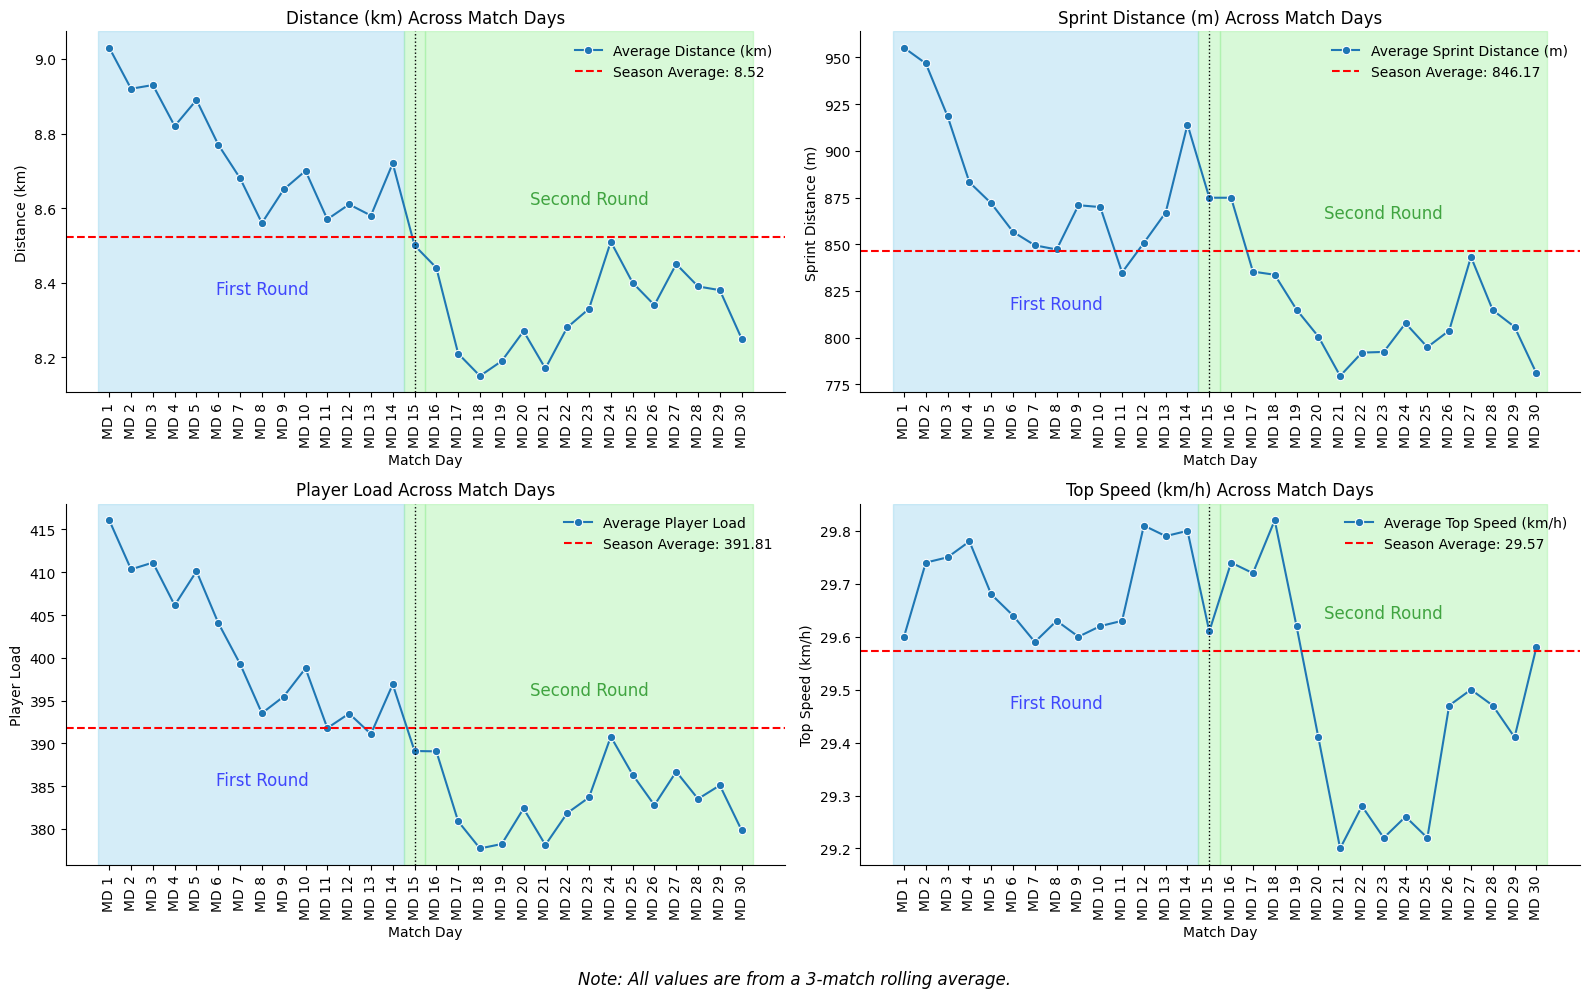

In [47]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
metrics = [
    ('distance_km', 'Distance (km)'),
    ('sprint_distance_m', 'Sprint Distance (m)'),
    ('player_load', 'Player Load'),
    ('top_speed_kmh', 'Top Speed (km/h)')
]

md15_idx = matchday_order.index('Md15')

for ax, (col, label) in zip(axes.flatten(), metrics):
    sns.lineplot(
        data=rolling_avg,
        x='match_day',
        y=col,
        marker='o',
        ax=ax,
        label=f'Average {label}'
    )
    avg_value = rolling_avg[col].mean()
    ax.axhline(avg_value, color='red', linestyle='--', label=f'Season Average: {avg_value:.2f}')
    # Draw vertical line at MD15
    ax.axvline(md15_idx, color='black', linestyle=':', linewidth=1)
    # Shade area before MD15 (First Round)
    ax.axvspan(-0.5, md15_idx - 0.5, color='skyblue', alpha=0.35)
    # Shade area after and including MD15 (Second Round)
    ax.axvspan(md15_idx - 0.5, md15_idx + 0.5, color='lightgreen', alpha=0.35)
    ax.axvspan(md15_idx + 0.5, len(matchday_order) - 0.5, color='lightgreen', alpha=0.35)
    xticklabels = [str(md).replace('Md', 'MD ') for md in rolling_avg['match_day']]
    ax.set_xticks(range(len(rolling_avg['match_day'])))
    ax.set_xticklabels(xticklabels, rotation=90)
    ax.set_title(f'{label} Across Match Days')
    ax.set_xlabel('Match Day')
    ax.set_ylabel(label)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    legend = ax.legend(frameon=False)
    ymin, ymax = ax.get_ylim()
    ax.text(md15_idx/2, avg_value - (ymax-ymin)*0.12, 'First Round', color='blue', fontsize=12, ha='center', va='top', alpha=0.7)
    ax.text(md15_idx + (len(matchday_order)-md15_idx)/2, avg_value + (ymax-ymin)*0.08, 'Second Round', color='green', fontsize=12, ha='center', va='bottom', alpha=0.7)

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.figtext(0.5, 0.01, "Note: All values are from a 3-match rolling average.", ha='center', fontsize=12, style='italic')
plt.show()


## Correlation Analysis

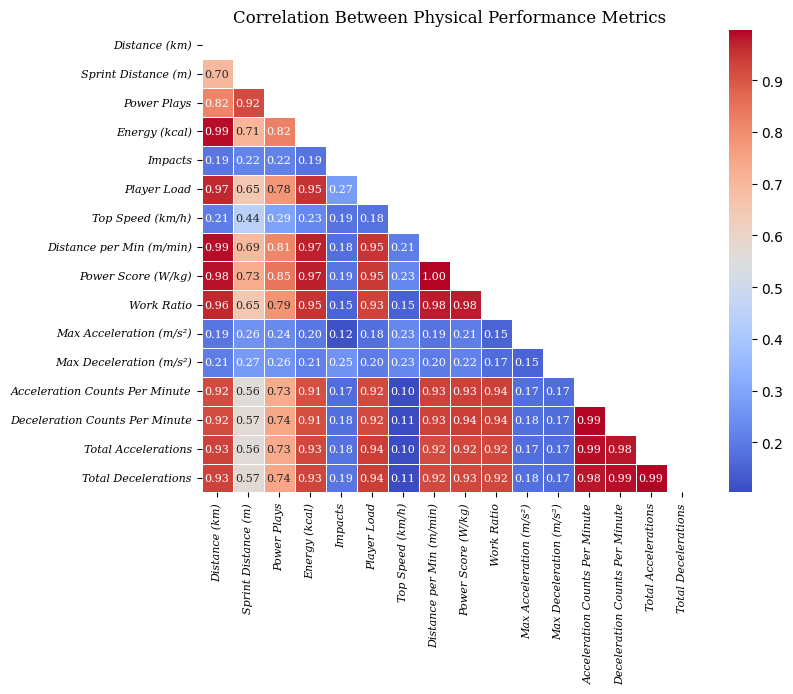

In [48]:
cols_to_corr = [col for col in num_cols if col != 'duration']
cols_to_corr.extend(['acc_counts_per_min','dec_counts_per_min','total_accelerations','total_decelerations'])
corr = df[cols_to_corr].corr(method='pearson')

# Mapping for pretty axis labels
pretty_labels = {
    'distance_km': 'Distance (km)',
    'sprint_distance_m': 'Sprint Distance (m)',
    'power_plays': 'Power Plays',
    'energy_kcal': 'Energy (kcal)',
    'impacts': 'Impacts',
    'player_load': 'Player Load',
    'top_speed_kmh': 'Top Speed (km/h)',
    'distance_per_min_mmin': 'Distance per Min (m/min)',
    'power_score_wkg': 'Power Score (W/kg)',
    'work_ratio': 'Work Ratio',
    'max_acceleration_mss': 'Max Acceleration (m/s²)',
    'max_deceleration_mss': 'Max Deceleration (m/s²)',
    'acc_counts_per_min':'Acceleration Counts Per Minute',
    'dec_counts_per_min':'Deceleration Counts Per Minute',
    'total_accelerations': 'Total Accelerations',
    'total_decelerations': 'Total Decelerations'
}

# Re-label the correlation matrix
corr = corr.rename(index=pretty_labels, columns=pretty_labels)

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    mask=mask,
    annot_kws={"fontsize":8, "fontfamily":"serif"}
)
plt.title("Correlation Between Physical Performance Metrics", fontsize=12, fontfamily="serif")
plt.xticks(fontsize=8, fontfamily="serif", fontstyle="italic")
plt.yticks(fontsize=8, fontfamily="serif", fontstyle="italic")
plt.show()


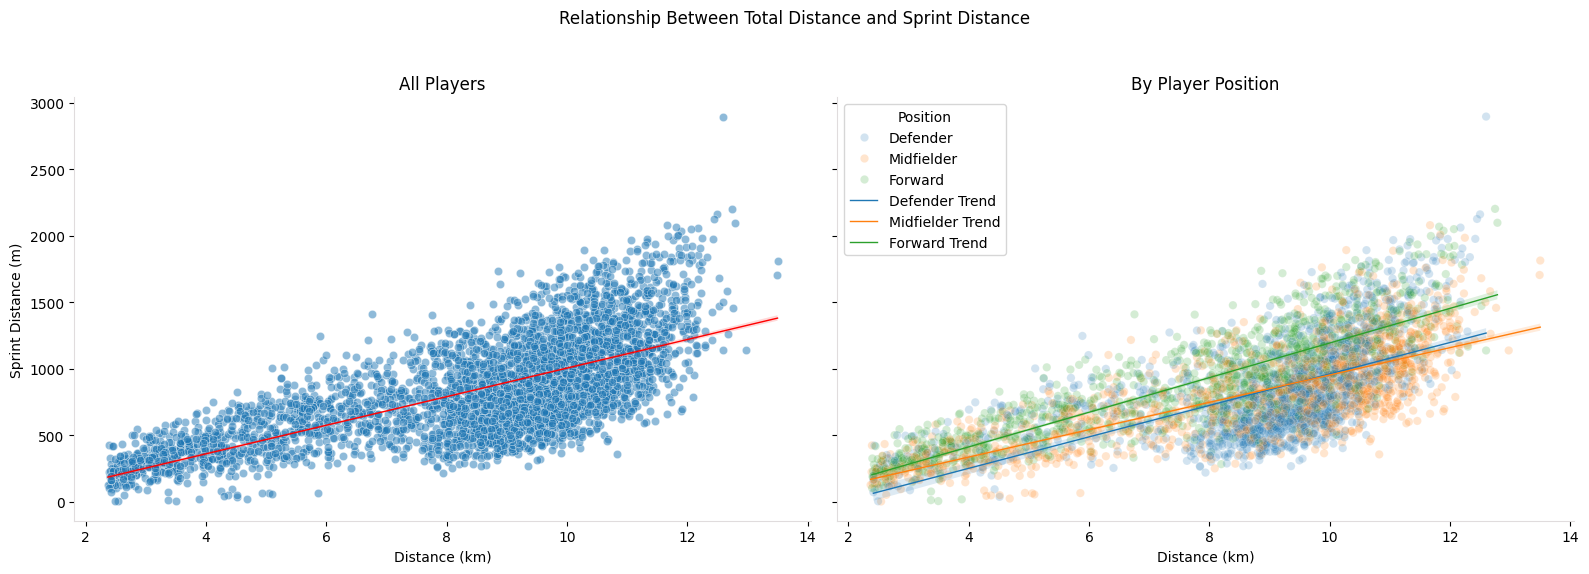

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Plot 1: All players, no hue
ax1 = axes[0]
sns.scatterplot(data=df, x='distance_km', y='sprint_distance_m', alpha=0.5, ax=ax1)
sns.regplot(data=df, x='distance_km', y='sprint_distance_m', scatter=False, ax=ax1, color='red', line_kws={'linewidth':1})
ax1.set_xlabel('Distance (km)')
ax1.set_ylabel('Sprint Distance (m)')
ax1.set_title('All Players')
ax1.grid(False)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_color('#E0DCDD')
ax1.spines['bottom'].set_color('#E0DCDD')

# Plot 2: Hue by player position, trend lines for each group
ax2 = axes[1]
sns.scatterplot(data=df, x='distance_km', y='sprint_distance_m', hue='general_position', alpha=0.2, ax=ax2)
for pos in df['general_position'].dropna().unique():
    sns.regplot(
        data=df[df['general_position'] == pos],
        x='distance_km',
        y='sprint_distance_m',
        scatter=False,
        ax=ax2,
        label=f"{pos} Trend",
        line_kws={'linewidth':1}
    )
ax2.set_xlabel('Distance (km)')
ax2.set_ylabel('Sprint Distance (m)')
ax2.set_title('By Player Position')
ax2.grid(False)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_color('#E0DCDD')
ax2.spines['bottom'].set_color('#E0DCDD')
ax2.legend(title='Position')

plt.suptitle('Relationship Between Total Distance and Sprint Distance')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Other Requests

### Pairwise Performance

In [50]:
# Calculate and display the average distance covered by players of both teams when they play each other, for all pairs

clubs = sorted(df['club_for'].unique())
single_matchday_metric = []

for i, club1 in enumerate(clubs):
    for club2 in clubs[i+1:]:
        # Find all matchdays where these two clubs played each other
        matchdays = df[
            ((df['club_for'] == club1) & (df['club_against'] == club2)) |
            ((df['club_for'] == club2) & (df['club_against'] == club1))
        ]['match_day'].unique()
        for md in matchdays:
            # Filter for only this pair and this matchday
            mask = (
                (((df['club_for'] == club1) & (df['club_against'] == club2)) |
                 ((df['club_for'] == club2) & (df['club_against'] == club1))) &
                (df['match_day'] == md)
            )
            relevant_rows = df[mask]
            if not relevant_rows.empty:
                avg_metrics = relevant_rows[intensity_metrics+volume_metrics].mean()
                row = {
                    'Team A': club1,
                    'Team B': club2,
                    'match_day': md
                }
                row.update(avg_metrics.to_dict())
                single_matchday_metric.append(row)

single_matchday_metric_df = pd.DataFrame(single_matchday_metric)
single_matchday_metric_df = single_matchday_metric_df[
    (single_matchday_metric_df['top_speed_kmh'] > 31)
][['Team A', 'Team B', 'match_day', 'top_speed_kmh', 'player_load','distance_km']]
single_matchday_metric_df = single_matchday_metric_df[(single_matchday_metric_df['distance_km'] > 9)]
single_matchday_metric_df = single_matchday_metric_df[(single_matchday_metric_df['player_load'] > 400)]
single_matchday_metric_df = single_matchday_metric_df.sort_values(by='player_load', ascending=False).reset_index(drop=True)

style_table_for_docs(single_matchday_metric_df.head(10))

,Team A,Team B,match_day,top_speed_kmh,player_load,distance_km
0,Bul Fc,Sc Villa,Md3,31.794670,481.947330,10.874350
1,Sc Villa,Soltilo Bright Stars Fc,Md5,31.391107,478.143336,10.471071
2,Bul Fc,Vipers Sc,Md12,31.082478,440.344961,9.529300
3,Kcca Fc,Vipers Sc,Md8,31.153756,439.017806,9.537731
4,Sc Villa,Vipers Sc,Md4,32.296775,422.191344,9.178325
5,Kcca Fc,Police Fc,Md14,31.200869,418.896938,9.619508


In [51]:
# Calculate and display the average distance covered by players of both teams when they play each other, for all pairs

clubs = sorted(df['club_for'].unique())
single_matchday_metric = []

for i, club1 in enumerate(clubs):
    for club2 in clubs[i+1:]:
        # Find all matchdays where these two clubs played each other
        matchdays = df[
            ((df['club_for'] == club1) & (df['club_against'] == club2)) |
            ((df['club_for'] == club2) & (df['club_against'] == club1))
        ]['match_day'].unique()
        for md in matchdays:
            # Filter for only this pair and this matchday
            mask = (
                (((df['club_for'] == club1) & (df['club_against'] == club2)) |
                 ((df['club_for'] == club2) & (df['club_against'] == club1))) &
                (df['match_day'] == md)
            )
            relevant_rows = df[mask]
            if not relevant_rows.empty:
                avg_metrics = relevant_rows[intensity_metrics+volume_metrics].mean()
                row = {
                    'Team A': club1,
                    'Team B': club2,
                    'match_day': md
                }
                row.update(avg_metrics.to_dict())
                single_matchday_metric.append(row)

single_matchday_metric_df = pd.DataFrame(single_matchday_metric)
single_matchday_metric_df = single_matchday_metric_df[
    (single_matchday_metric_df['top_speed_kmh'] > 0)
][['Team A', 'Team B', 'match_day', 'top_speed_kmh', 'player_load','distance_km']]
single_matchday_metric_df = single_matchday_metric_df[(single_matchday_metric_df['distance_km'] < 9)]
single_matchday_metric_df = single_matchday_metric_df[(single_matchday_metric_df['player_load'] < 400)]
single_matchday_metric_df = single_matchday_metric_df.sort_values(by='distance_km', ascending=True).reset_index(drop=True)

style_table_for_docs(single_matchday_metric_df.head(10))

,Team A,Team B,match_day,top_speed_kmh,player_load,distance_km
0,Updf Fc,Wakiso Giants Fc,Md21,28.795322,317.740611,6.439689
1,Express Fc,Nec Fc,Md21,29.203292,301.004869,6.512246
2,Nec Fc,Vipers Sc,Md24,29.843882,321.055355,6.898345
3,Express Fc,Updf Fc,Md15,29.591430,321.178460,6.959890
4,Kitara Fc,Mbale Heroes Fc,Md30,29.039500,319.823473,7.027227
5,Mbarara City Fc,Police Fc,Md23,27.619415,344.223785,7.067615
6,Bul Fc,Lugazi Fc,Md26,29.588219,327.394700,7.090485
7,Kitara Fc,Ura Fc,Md18,29.394996,330.502346,7.094046
8,Nec Fc,Updf Fc,Md22,29.626514,311.741305,7.097462
9,Express Fc,Lugazi Fc,Md19,29.748793,329.181371,7.157993


In [52]:
# Create a DataFrame showing the averages of all intensity metrics for each team A when they play team B
clubs = sorted(df['club_for'].unique())
avg_intensity_vs_opponent = []

for club1 in clubs:
    for club2 in clubs:
        if club1 == club2:
            continue  # skip self
        mask = (
            ((df['club_for'] == club1) & (df['club_against'] == club2))
        )
        club1_rows = df[mask]
        if not club1_rows.empty:
            avg_metrics = club1_rows[intensity_metrics].mean()
            row = {'Team A': club1, 'Team B': club2}
            row.update(avg_metrics.to_dict())
            avg_intensity_vs_opponent.append(row)

avg_intensity_vs_opponent_df = pd.DataFrame(avg_intensity_vs_opponent)
avg_intensity_vs_opponent_df = avg_intensity_vs_opponent_df.sort_values(by='top_speed_kmh', ascending=False).reset_index(drop=True)
style_table_for_docs(avg_intensity_vs_opponent_df.head(10))

,Team A,Team B,player_load,top_speed_kmh,distance_per_min_mmin,power_score_wkg,work_ratio,max_acceleration_mss,max_deceleration_mss,acc_counts_per_min,dec_counts_per_min
0,Vipers Sc,Mbarara City Fc,408.327994,31.519367,89.815806,14.430394,71.677989,5.814061,7.548272,3.907230,3.782750
1,Sc Villa,Nec Fc,461.099689,31.513144,101.994928,16.656800,84.171856,6.015911,7.785944,4.840593,4.646207
2,Sc Villa,Vipers Sc,427.248231,31.343023,97.473908,15.833446,81.739277,6.079400,7.868877,4.564923,4.305499
3,Sc Villa,Lugazi Fc,440.208720,31.294660,108.076973,17.460260,94.418540,5.643440,7.739240,4.697431,4.483966
4,Vipers Sc,Maroons Fc,440.813056,31.150022,96.773676,15.531822,78.701628,6.077567,7.134439,4.279473,4.115839
5,Kcca Fc,Police Fc,417.147953,31.088724,93.344297,15.365206,81.035412,6.029341,7.296647,4.420470,4.267754
6,Kcca Fc,Express Fc,388.348494,31.080256,87.729337,14.477633,75.776667,5.869378,7.739922,4.156914,3.967980
7,Vipers Sc,Kcca Fc,435.549061,31.002917,94.148998,15.321228,74.459767,6.145644,7.285139,4.455938,4.218770
8,Ura Fc,Nec Fc,389.826029,30.940814,86.565923,13.991729,70.834071,6.358729,7.533643,4.243697,4.011881
9,Vipers Sc,Ura Fc,406.705625,30.859225,95.359684,15.337225,78.686450,6.178150,7.079063,4.465505,4.182537


In [53]:
# Create a DataFrame showing the averages of all volume metrics for each team A when they play team B
clubs = sorted(df['club_for'].unique())
avg_volume_vs_opponent = []

for club1 in clubs:
    for club2 in clubs:
        if club1 == club2:
            continue  # skip self
        mask = (
            ((df['club_for'] == club1) & (df['club_against'] == club2))
        )
        club1_rows = df[mask]
        if not club1_rows.empty:
            avg_metrics = club1_rows[volume_metrics].mean()
            row = {'Team A': club1, 'Team B': club2}
            row.update(avg_metrics.to_dict())
            avg_volume_vs_opponent.append(row)

avg_volume_vs_opponent_df = pd.DataFrame(avg_volume_vs_opponent)
avg_volume_vs_opponent_df = avg_volume_vs_opponent_df.sort_values(by='distance_km', ascending=False).reset_index(drop=True)
style_table_for_docs(avg_volume_vs_opponent_df.head(10))

,Team A,Team B,distance_km,sprint_distance_m,power_plays,energy_kcal,impacts,total_accelerations,total_decelerations
0,Sc Villa,Mbarara City Fc,11.679600,1371.560200,91.800000,1420.546680,6.600000,510.400000,466.800000
1,Sc Villa,Ura Fc,11.035560,1314.082000,76.600000,1332.733040,6.800000,462.800000,440.400000
2,Express Fc,Maroons Fc,10.834700,1260.029571,83.714286,1364.696471,4.428571,563.285714,543.857143
3,Sc Villa,Bul Fc,10.764690,1059.543000,72.700000,1301.357580,7.600000,482.400000,473.700000
4,Sc Villa,Police Fc,10.561644,1300.650333,76.555556,1271.207244,7.666667,435.000000,413.777778
5,Sc Villa,Updf Fc,10.443590,1099.021700,70.500000,1257.063690,5.300000,460.200000,440.500000
6,Maroons Fc,Nec Fc,10.392280,1218.092700,85.200000,1287.209550,2.600000,542.400000,524.500000
7,Soltilo Bright Stars Fc,Maroons Fc,10.326017,891.081000,64.833333,1212.222450,7.333333,409.666667,395.666667
8,Police Fc,Express Fc,10.300425,1082.542625,76.125000,1265.755263,11.750000,502.125000,474.250000
9,Soltilo Bright Stars Fc,Updf Fc,10.285075,1001.076500,69.562500,1231.373469,8.875000,444.000000,433.750000


### Top Performers for each Metric( Individual/Team/Pairwise)

In [54]:
# Find top 5 players for each metric in volume_metrics and intensity_metrics
top5_players = []

metrics_to_check = volume_metrics + intensity_metrics
for metric in metrics_to_check:
    # Get top 5 rows for this metric
    top_rows = df.nlargest(5, metric)
    for _, row in top_rows.iterrows():
        top5_players.append({
            'metric': metric,
            'player': row['p_name'],
            'club': row['club_for'],
            'value': row[metric],
            'match day': row['match_day']
        })

top5_players_df = pd.DataFrame(top5_players)
# Optionally, sort for display
top5_players_df = top5_players_df.sort_values(['metric', 'value'], ascending=[True, False]).reset_index(drop=True)
style_table_for_docs(top5_players_df)

,metric,player,club,value,match day
0,acc_counts_per_min,Felix Okot,Maroons Fc,7.110439,Md29
1,acc_counts_per_min,Frank Tumwesigye,Kitara Fc,7.096774,Md27
2,acc_counts_per_min,Asiimwe John,Express Fc,7.032843,Md5
3,acc_counts_per_min,Richard Okello,Bul Fc,6.722277,Md16
4,acc_counts_per_min,Asiimwe John,Express Fc,6.715956,Md3
5,dec_counts_per_min,Frank Tumwesigye,Kitara Fc,6.707629,Md27
6,dec_counts_per_min,Asiimwe John,Express Fc,6.659117,Md5
7,dec_counts_per_min,Felix Okot,Maroons Fc,6.616238,Md29
8,dec_counts_per_min,Richard Okello,Bul Fc,6.545633,Md16
9,dec_counts_per_min,Ochungo Thomas,Bul Fc,6.493919,Md29


### Best performers in each position

In [55]:
# Combine metrics into one list
all_metrics = volume_metrics + intensity_metrics

# Store top 5 players per metric and position
top5_players_by_position = []

for metric in all_metrics:
    for position in df['general_position'].dropna().unique():
        # Get top 5 players for this metric and position
        top_rows = df[df['general_position'] == position].nlargest(5, metric)
        
        for _, row in top_rows.iterrows():
            top5_players_by_position.append({
                'metric': metric,
                'player': row['p_name'],
                'club': row['club_for'],
                'value': row[metric],
                'match day': row['match_day'],
                'position': position
            })

# Convert to DataFrame
top5_players_by_position_df = pd.DataFrame(top5_players_by_position)

# Sort by metric name (alphabetically) and then value (descending)
top5_players_by_position_df = top5_players_by_position_df.sort_values(
    ['metric', 'value'], ascending=[True, False]
).reset_index(drop=True)

# Apply your styling function
style_table_for_docs(top5_players_by_position_df)



,metric,player,club,value,match day,position
0,acc_counts_per_min,Felix Okot,Maroons Fc,7.110439,Md29,Midfielder
1,acc_counts_per_min,Frank Tumwesigye,Kitara Fc,7.096774,Md27,Midfielder
2,acc_counts_per_min,Asiimwe John,Express Fc,7.032843,Md5,Midfielder
3,acc_counts_per_min,Richard Okello,Bul Fc,6.722277,Md16,Midfielder
4,acc_counts_per_min,Asiimwe John,Express Fc,6.715956,Md3,Midfielder
5,acc_counts_per_min,Ochungo Thomas,Bul Fc,6.595890,Md27,Defender
6,acc_counts_per_min,Ochungo Thomas,Bul Fc,6.578530,Md29,Defender
7,acc_counts_per_min,Ochungo Thomas,Bul Fc,6.376022,Md30,Defender
8,acc_counts_per_min,Edward Kabona,Maroons Fc,6.374181,Md29,Defender
9,acc_counts_per_min,Edward Kabona,Maroons Fc,6.369405,Md13,Defender


In [56]:
# Combine metrics into one list
all_metrics = volume_metrics + intensity_metrics

# Group by player and position, then average all metrics
avg_df = df.groupby(['p_name', 'general_position', 'club_for'])[all_metrics].mean().reset_index()

# Store top 5 players per metric and position
top5_players_by_position = []

for metric in all_metrics:
    for position in avg_df['general_position'].dropna().unique():
        # Get top 5 players for this metric and position
        top_rows = avg_df[avg_df['general_position'] == position].nlargest(5, metric)
        
        for _, row in top_rows.iterrows():
            top5_players_by_position.append({
                'metric': metric,
                'player': row['p_name'],
                'club': row['club_for'],
                'value': row[metric],
                'position': position
            })

# Convert to DataFrame
top5_players_by_position_df = pd.DataFrame(top5_players_by_position)

# Sort for display: alphabetically by metric, descending by value
top5_players_by_position_df = top5_players_by_position_df.sort_values(
    ['metric', 'value'], ascending=[True, False]
).reset_index(drop=True)

# Display nicely (assuming this is your custom function)
style_table_for_docs(top5_players_by_position_df)


,metric,player,club,value,position
0,acc_counts_per_min,Ochungo Thomas,Bul Fc,6.088936,Defender
1,acc_counts_per_min,Samuel Kayongo,Police Fc,5.766901,Midfielder
2,acc_counts_per_min,Richard Okello,Bul Fc,5.732954,Midfielder
3,acc_counts_per_min,Ssenyonjo Samuel,Express Fc,5.647488,Forward
4,acc_counts_per_min,Hakim Musabbah,Mbale Heroes Fc,5.602221,Forward
5,acc_counts_per_min,Felix Okot,Maroons Fc,5.520502,Midfielder
6,acc_counts_per_min,Edward Kabona,Maroons Fc,5.481814,Defender
7,acc_counts_per_min,Alex Mandera,Soltilo Bright Stars Fc,5.479379,Midfielder
8,acc_counts_per_min,Tonny Atukunda,Sc Villa,5.426235,Midfielder
9,acc_counts_per_min,Gavin Kizito,Kcca Fc,5.349590,Defender


In [57]:
# Custom position sorting order
position_order = ['Defender', 'Midfielder', 'Forward']

# Step 1: Count appearances (unique match days)
appearances_df = df.groupby(['p_name', 'general_position', 'club_for'])['match_day'].nunique().reset_index()
appearances_df = appearances_df.rename(columns={'match_day': 'appearances'})

# Step 2: Calculate mean and std for metrics
metrics_stats_df = df.groupby(['p_name', 'general_position', 'club_for'])[all_metrics].agg(['mean', 'std']).reset_index()

# Step 3: Fix column names: flatten multi-index columns
metrics_stats_df.columns = [
    f"{metric}_{stat}" if stat else metric
    for metric, stat in metrics_stats_df.columns.to_flat_index()
]

# Step 4: Merge with appearances
merged_df = metrics_stats_df.merge(
    appearances_df,
    on=['p_name', 'general_position', 'club_for']
)

# Step 5: Only include players with at least 3 appearances
filtered_df = merged_df[merged_df['appearances'] >= 15]

# Step 6: Extract top 5 players for each metric and position
top5_players_by_position = []

for metric in all_metrics:
    mean_col = f'{metric}_mean'
    std_col = f'{metric}_std'

    for position in position_order:
        group = filtered_df[filtered_df['general_position'] == position]

        # Skip if metric column is missing
        if mean_col not in group.columns:
            continue

        top_rows = group.nlargest(5, mean_col)

        for _, row in top_rows.iterrows():
            top5_players_by_position.append({
                'metric': metric,
                'player': row['p_name'],
                'club': row['club_for'],
                'mean_value': row[mean_col],
                'std_dev': row[std_col],
                'appearances': row['appearances'],
                'position': position
            })

# Step 7: Create and sort final DataFrame
top5_df = pd.DataFrame(top5_players_by_position)

# Sort positions using custom category
top5_df['position'] = pd.Categorical(
    top5_df['position'], categories=position_order, ordered=True
)

# Sort by metric → position → mean value
top5_df = top5_df.sort_values(['metric', 'position', 'mean_value'], ascending=[True, True, False]).reset_index(drop=True)

# Show results
style_table_for_docs(top5_df.round(2))


,metric,player,club,mean_value,std_dev,appearances,position
0,acc_counts_per_min,Edward Kabona,Maroons Fc,5.480000,0.530000,23,Defender
1,acc_counts_per_min,Gavin Kizito,Kcca Fc,5.350000,0.390000,22,Defender
2,acc_counts_per_min,James Mubezi,Kcca Fc,5.240000,0.400000,22,Defender
3,acc_counts_per_min,Jonathan Gift Odongo,Soltilo Bright Stars Fc,5.190000,0.290000,15,Defender
4,acc_counts_per_min,Borris Onegi,Maroons Fc,5.180000,0.530000,18,Defender
5,acc_counts_per_min,Felix Okot,Maroons Fc,5.520000,0.920000,16,Midfielder
6,acc_counts_per_min,Enock Ssebaggala,Nec Fc,5.340000,0.630000,22,Midfielder
7,acc_counts_per_min,Ali Arshavin Bayo,Lugazi Fc,5.270000,0.330000,26,Midfielder
8,acc_counts_per_min,Frank Gladison Mugisa,Updf Fc,5.190000,0.390000,18,Midfielder
9,acc_counts_per_min,Abel Michael Etrude,Maroons Fc,5.120000,0.800000,16,Midfielder


## Speed Zones

### Distance in Speed Zones

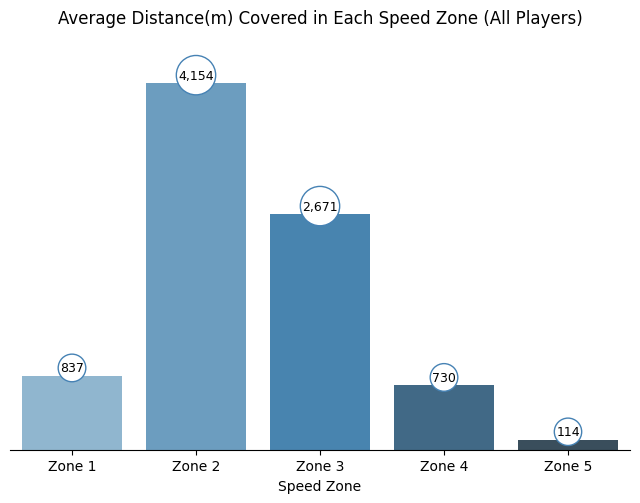

In [58]:
# List of speed zone columns
speed_zone_cols = [
    'distance_in_speed_zone_1_km',
    'distance_in_speed_zone_2_km',
    'distance_in_speed_zone_3_km',
    'distance_in_speed_zone_4_km',
    'distance_in_speed_zone_5_km'
]

# Compute average distance for each speed zone
avg_speed_zone_dist = df[speed_zone_cols].mean()

# Prepare labels (replace _ with space, add zone number)
zone_labels = [f"Zone {i+1}" for i in range(len(speed_zone_cols))]

plt.figure(figsize=(8, 5))


# Create barplot
# plt.figure(figsize=(12,6))
sns.barplot(x=zone_labels,hue=zone_labels, y=avg_speed_zone_dist.values, palette='Blues_d',legend=False)

# Title, subtitle, and axis labels
# plt.ylabel("Average Distance (m)")
plt.xlabel("Speed Zone")
plt.title("Average Distance(m) Covered in Each Speed Zone (All Players)", pad=30)

ax= plt.gca()

# Gridlines for y-axis
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

# Annotate values inside bars
for i, v in enumerate(avg_speed_zone_dist):
    # Convert km to m and format with comma

    ax.annotate(
        f"{int(round(v),):,}",
        xy=(i, v),
        xytext=(0, 1),
        textcoords='offset points',
        ha='center',
        va='bottom',
        fontsize=9,
        bbox=dict(boxstyle="circle,pad=0.15", edgecolor='#4682B4', facecolor='white', linewidth=1)
    )

#remove yaxis ticklabels
ax.set_yticklabels([])
ax.set_yticks([])

plt.show()


C:\Users\Travail\AppData\Local\Temp\ipykernel_14048\2362410231.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


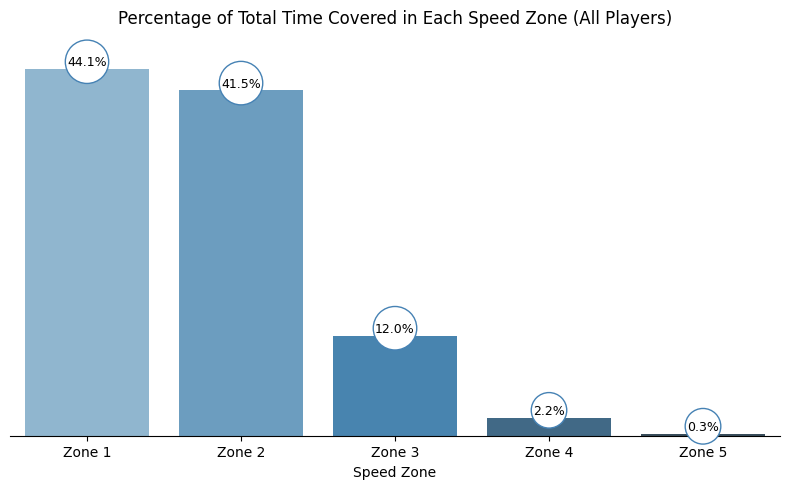

In [59]:

# List of speed zone columns 
speed_zone_cols = [
    'time_in_speed_zone_1_secs',
    'time_in_speed_zone_2_secs',
    'time_in_speed_zone_3_secs',
    'time_in_speed_zone_4_secs',
    'time_in_speed_zone_5_secs'
]

# Compute average time (secs) for each speed zone
avg_time_secs = df[speed_zone_cols].mean()

# Total average time across all zones
total_time = avg_time_secs.sum()

# Prepare labels
zone_labels = [f"Zone {i+1}" for i in range(len(speed_zone_cols))]

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    x=zone_labels,
    y=avg_time_secs.values / 60,      # convert to minutes on the y-axis
    palette='Blues_d',
    dodge=False
)

# Title and axis labels
ax.set_xlabel("Speed Zone")
ax.set_title("Percentage of Total Time Covered in Each Speed Zone (All Players)", pad=20)

# Gridlines
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

# Remove top and right spines
sns.despine(ax=ax, top=True, right=True, left=True)

# Annotate with percentages
for i, secs in enumerate(avg_time_secs):
    pct = (secs / total_time) * 100
    ax.text(
        i, 
        (secs / 60) + 0.1,           # place label just above the bar (in minutes)
        f"{pct:.1f}%",               
        ha='center', 
        va='bottom', 
        fontsize=9,
        bbox=dict(boxstyle="circle,pad=0.15", edgecolor='#4682B4', facecolor='white', linewidth=1)
    )

# Optionally remove y-ticks if you only want to show percentage
ax.set_yticks([])

plt.tight_layout()
plt.show()


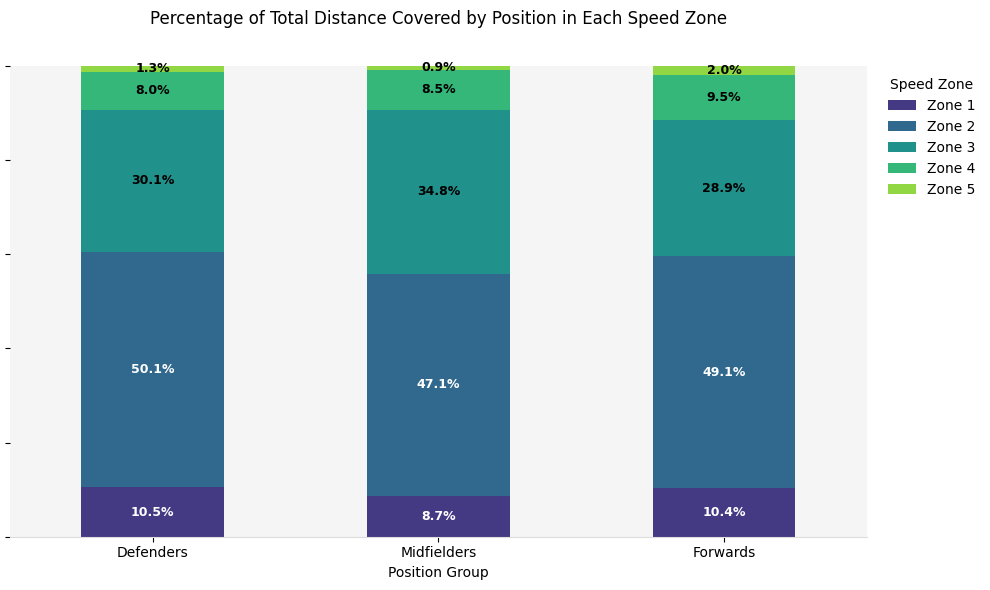

In [60]:
# Prepare data for 100% stacked bar plot: percentage distance in each speed zone grouped by position
speed_zone_cols = [
    'distance_in_speed_zone_1_km',
    'distance_in_speed_zone_2_km',
    'distance_in_speed_zone_3_km',
    'distance_in_speed_zone_4_km',
    'distance_in_speed_zone_5_km'
]

# Group by position and sum distances (in km)
zone_by_position = df.groupby('general_position')[speed_zone_cols].sum()

# Reorder positions if desired
position_order = ['Defender', 'Midfielder', 'Forward']
zone_by_position = zone_by_position.reindex(position_order)

# Add 's' to each position group name
zone_by_position.index = [f"{pos}s" for pos in zone_by_position.index]

# Prepare labels
zone_labels = [f"Zone {i+1}" for i in range(len(speed_zone_cols))]
zone_by_position.columns = zone_labels

# Convert to percentages row-wise
zone_pct = zone_by_position.div(zone_by_position.sum(axis=1), axis=0) * 100

# Plot
ax = zone_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    color=sns.color_palette('viridis', n_colors=len(zone_labels))
)

# Annotate values inside each bar segment (as percentages, one decimal)
for i, pos in enumerate(zone_pct.index):
    cumulative = 0
    for j, zone in enumerate(zone_labels):
        value = zone_pct.loc[pos, zone]
        height = value
        y = cumulative + height / 2
        if value > 0.05:  # Only annotate if segment is large enough
            ax.text(
                i, y, f"{value:.1f}%",
                ha='center', va='center', fontsize=9, color='black' if j > 1 else 'white', fontweight='bold'
            )
        cumulative += height

plt.xlabel('Position Group')
plt.title('Percentage of Total Distance Covered by Position in Each Speed Zone',pad=30)
plt.xticks(rotation=0)
plt.legend(title='Speed Zone', frameon=False, bbox_to_anchor=(1.01, 1), loc='upper left')
# Remove top, left, and right spines
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color('#E0DCDD')
ax.set_facecolor('#F5F5F5')

# Remove yaxis ticklabels and set y-axis to 0-100%
ax.set_yticklabels([])
ax.set_yticks([])

ax.set_yticks(range(0, 101, 20))
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

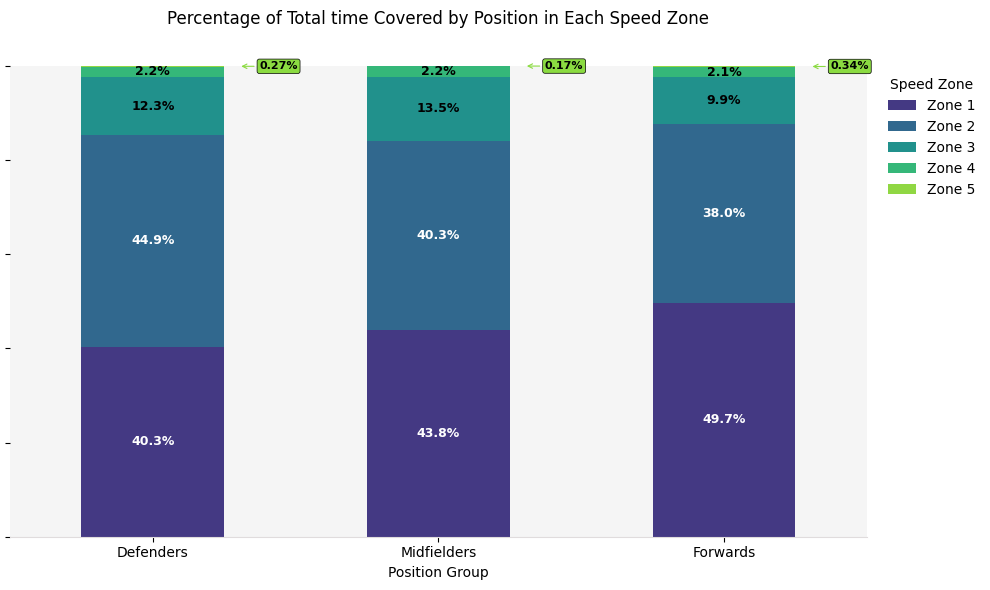

In [61]:
from matplotlib.patches import Patch

# Prepare data for 100% stacked bar plot: percentage time in each speed zone grouped by position
speed_zone_cols = [
    'time_in_speed_zone_1_secs',
    'time_in_speed_zone_2_secs',
    'time_in_speed_zone_3_secs',
    'time_in_speed_zone_4_secs',
    'time_in_speed_zone_5_secs'
]

# Group by position and sum times (in secs)
zone_by_position = df.groupby('general_position')[speed_zone_cols].sum()

# Reorder positions if desired
position_order = ['Defender', 'Midfielder', 'Forward']
zone_by_position = zone_by_position.reindex(position_order)

# Add 's' to each position group name
zone_by_position.index = [f"{pos}s" for pos in zone_by_position.index]

# Prepare labels
zone_labels = [f"Zone {i+1}" for i in range(len(speed_zone_cols))]
zone_by_position.columns = zone_labels

# Convert to percentages row-wise
zone_pct = zone_by_position.div(zone_by_position.sum(axis=1), axis=0) * 100

# Plot
ax = zone_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    color=sns.color_palette('viridis', n_colors=len(zone_labels))
)

# Annotate values inside each bar segment (as percentages, one decimal)
for i, pos in enumerate(zone_pct.index):
    cumulative = 0
    for j, zone in enumerate(zone_labels):
        value = zone_pct.loc[pos, zone]
        height = value
        y = cumulative + height / 2
        if value > 0.5:  # Only annotate if segment is large enough
            ax.text(
            i, y, f"{value:.1f}%",
            ha='center', va='center', fontsize=9, color='black' if j > 1 else 'white', fontweight='bold'
            )
        else:
            # Place a callout to the right side of the bar for small segments in Zone 5
            if zone == "Zone 5":
                ax.annotate(
                    f"{value:.2f}%",
                    xy=(i + 0.3, cumulative + height / 2),  # right side of the bar
                    xytext=(15, 0),  # offset to the right
                    textcoords='offset points',
                    ha='left',
                    va='center',
                    fontsize=8,
                    fontweight='bold',
                    color='black',
                    # Use a rounded rectangle for the callout box
                    bbox=dict(boxstyle="round,pad=0.2", facecolor="#8BDB41", linewidth=0.5),
                    arrowprops=dict(arrowstyle='->', color='#8BDB41', lw=0.8)
                )
        cumulative += height

plt.xlabel('Position Group')
plt.title('Percentage of Total time Covered by Position in Each Speed Zone',pad=30)
plt.xticks(rotation=0)
plt.legend(title='Speed Zone', frameon=False, bbox_to_anchor=(1.01, 1), loc='upper left')
# Remove top, left, and right spines
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color('#E0DCDD')
ax.set_facecolor('#F5F5F5')

# Remove yaxis ticklabels and set y-axis to 0-100%
ax.set_yticklabels([])
ax.set_yticks([])

ax.set_yticks(range(0, 101, 20))
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

### Individuals

In [62]:
edward_data = df[(df['p_name'] == 'Allan Okello')][volume_metrics + intensity_metrics].mean().round(2)
style_table_for_docs(edward_data.to_frame().T)

,distance_km,sprint_distance_m,power_plays,energy_kcal,impacts,total_accelerations,total_decelerations,player_load,top_speed_kmh,distance_per_min_mmin,power_score_wkg,work_ratio,max_acceleration_mss,max_deceleration_mss,acc_counts_per_min,dec_counts_per_min
0,9.270000,805.450000,58.480000,1105.420000,7.360000,402.240000,381.440000,428.690000,30.250000,92.850000,14.710000,72.520000,5.910000,6.780000,4.030000,3.820000


In [63]:
df[(df['p_name'] == 'Ronald Ssekiganda')]['distance_km'].mean()


np.float64(11.53844)

C:\Users\Travail\AppData\Local\Temp\ipykernel_14048\2278080164.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ronald_data = df[df['p_name'] == 'Ronald Ssekiganda'].groupby('match_day')['distance_km'].mean().round(1).reset_index()


<Axes: title={'center': 'Average Distance Covered by Ronald Ssekiganda per Match Day'}, xlabel='Match Day', ylabel='Average Distance (km)'>

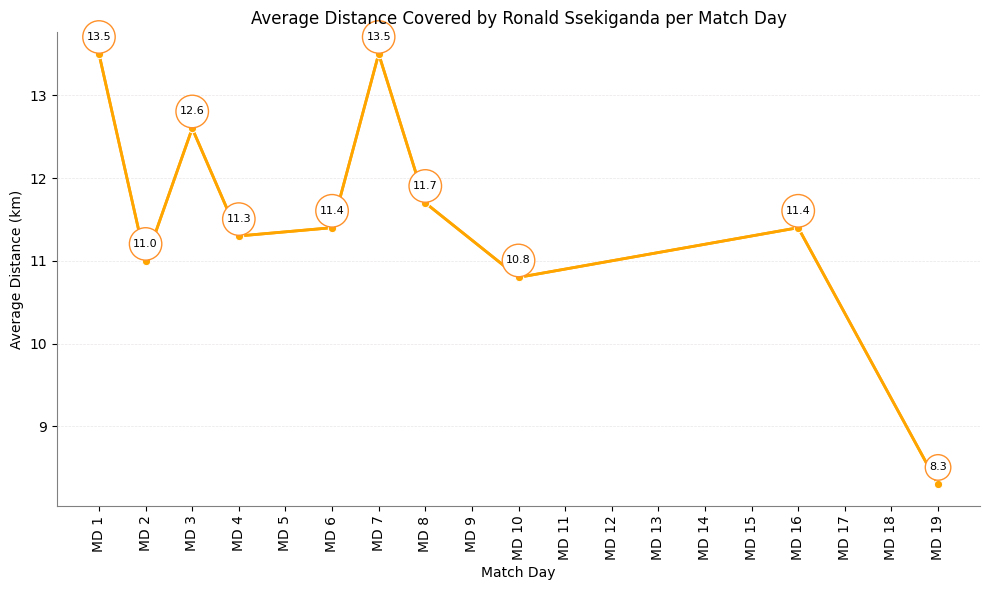

In [64]:
# plot a line graph showing the average distance covered by Ronald Ssekiganda in each match day
ronald_data = df[df['p_name'] == 'Ronald Ssekiganda'].groupby('match_day')['distance_km'].mean().round(1).reset_index()
ronald_data['match_day'] = pd.Categorical(ronald_data['match_day'],
                                             categories=matchday_order, ordered=True)
ronald_data = ronald_data.sort_values('match_day')
plot_line_with_values(
    ronald_data,
    x_col='match_day',
    y_col='distance_km',
    title='Average Distance Covered by Ronald Ssekiganda per Match Day',
    x_label='Match Day',
    y_label='Average Distance (km)',
    
)


In [65]:
df[(df['p_name'] == 'Ronald Ssekiganda')][['match_day','distance_km','duration']].sort_values(by='match_day').reset_index(drop=True)


,match_day,distance_km,duration
0,Md1,13.4886,98.800000
1,Md2,10.9743,88.483333
2,Md3,12.5864,103.900000
3,Md4,11.3489,94.533333
4,Md6,11.4388,94.650000
5,Md7,13.4990,106.166667
6,Md8,11.6518,103.550000
7,Md10,10.7552,94.133333
8,Md16,11.3699,100.266667
9,Md19,8.2715,101.283333


In [66]:
df[['p_name','sprint_distance_m']].sort_values(by='sprint_distance_m',ascending=False).head(6)

,p_name,sprint_distance_m
1784,Innocent Wafula Esimu,2894.443
1986,James Penz Begisa,2200.869
1010,Elagu Gabriel,2159.436
2749,Musa Ssegujja,2125.148
2190,Jude Semugabi,2096.366
572,Brian Ljara,2078.269
